In [1]:
import pandas as pd
import numpy as np

# 1. 读取数据
file_path = '01_喷油泵.xlsx'
df_raw = pd.read_excel(file_path)

# 定义原始总行数，解决 NameError
total_raw = len(df_raw)

# 为了方便对照 Excel，我们将索引 + 2 (Excel从1开始且有表头)
df_raw['excel_row'] = df_raw.index + 2 

# 2. 稳健的日期转换函数
def to_total_days(val):
    if pd.isna(val) or val == 0: return None
    try:
        val = int(float(val))
        if val >= 10000:
            year, month, day = val // 10000, (val % 10000) // 100, val % 100
        else:
            year, month, day = 0, val // 100, val % 100
        if month < 1 or month > 12: return None
        return year * 365 + month * 30 + day
    except:
        return None

# 3. 开始“标签化”清洗
df_working = df_raw.copy()
df_working['reason'] = 'Keep' # 初始标记为保留

# A. 标记非目标零件
mask_not_pump = ~df_working['故障件'].str.contains('喷油泵', na=False)
df_working.loc[mask_not_pump & (df_working['reason'] == 'Keep'), 'reason'] = '非喷油泵记录'

# B. 计算日期并标记解析失败
df_working['f_days'] = df_working['维修时间'].apply(to_total_days)
df_working['s_days'] = df_working['启用日'].apply(to_total_days).fillna(df_working['出厂日'].apply(to_total_days))

mask_date_err = df_working['f_days'].isna() | df_working['s_days'].isna()
df_working.loc[mask_date_err & (df_working['reason'] == 'Keep'), 'reason'] = '日期缺失或格式错误'

# C. 计算失效时间并标记逻辑错误
df_working['fail_time'] = df_working['f_days'] - df_working['s_days']
# 跨年修正
df_working.loc[(df_working['fail_time'] < 0) & (df_working['fail_time'] > -365) & (df_working['reason'] == 'Keep'), 'fail_time'] += 365

mask_neg_time = df_working['fail_time'] < 0
df_working.loc[mask_neg_time & (df_working['reason'] == 'Keep'), 'reason'] = '逻辑错误(维修早于启用)'

# D. 标记里程非法
df_working['mileage_val'] = pd.to_numeric(df_working['里程'], errors='coerce')
mask_mileage_err = df_working['mileage_val'].isna() | (df_working['mileage_val'] < 0)
df_working.loc[mask_mileage_err & (df_working['reason'] == 'Keep'), 'reason'] = '里程缺失或非法'

# E. 标记 0 值
mask_zero = (df_working['fail_time'] == 0) | (df_working['mileage_val'] == 0)
df_working.loc[mask_zero & (df_working['reason'] == 'Keep'), 'reason'] = '0里程或0天失效'

# 4. 分离出“干净数据”和“错误日志”
df_cleaned = df_working[df_working['reason'] == 'Keep'].copy()
df_error_log = df_working[df_working['reason'] != 'Keep'].copy()

# 统一变量名，方便后续 Cell 调用
df_final = df_cleaned 

# 5. 输出审计报告
print("="*50)
print(f"原始数据总记录数: {total_raw}")
print("-" * 50)
print(f"最终有效记录数: {len(df_final)}")
print(f"数据留存率: {len(df_final)/total_raw:.2%}")
print("="*50)

print(f"{'清洗原因分类':<25} | {'行数':<10}")
print("-" * 50)
report = df_working['reason'].value_counts()
for reason, count in report.items():
    if reason != 'Keep':
        print(f"{reason:<25} | {count:<10}")
print("-" * 50)
print(f"{'最终保留有效记录 (Keep)':<25} | {len(df_final):<10}")
print("="*50)

# 6. 保存文件
df_final.to_csv('cleaned_data.csv', index=False, encoding='utf-8-sig')
df_error_log.to_csv('error_data_log.csv', index=False, encoding='utf-8-sig')

print("\n[完成] 干净数据已存至: cleaned_data.csv")
print("[完成] 错误追溯表已存至: error_data_log.csv")

# 展示几条错误数据样板
print("\n--- 错误数据样例 (Top 5) ---")
display(df_error_log[['excel_row', '维修时间', '启用日', '里程', 'reason']].head())

原始数据总记录数: 5480
--------------------------------------------------
最终有效记录数: 5172
数据留存率: 94.38%
清洗原因分类                    | 行数        
--------------------------------------------------
0里程或0天失效                  | 167       
逻辑错误(维修早于启用)              | 120       
非喷油泵记录                    | 11        
日期缺失或格式错误                 | 10        
--------------------------------------------------
最终保留有效记录 (Keep)           | 5172      

[完成] 干净数据已存至: cleaned_data.csv
[完成] 错误追溯表已存至: error_data_log.csv

--- 错误数据样例 (Top 5) ---


,excel_row,维修时间,启用日,里程,reason
7,9,10121,NaN,0,日期缺失或格式错误
30,32,10227,10120.0,0,0里程或0天失效
40,42,10213,10207.0,0,0里程或0天失效
46,48,10330,NaN,0,日期缺失或格式错误
55,57,10302,NaN,48000,日期缺失或格式错误


In [10]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib qt
# 或者 %matplotlib tk


plt.rcParams['font.family'] = 'Times New Roman'


# ================================
# 1. Calculate & Print Statistics
# ================================
mean_fail_time = df_final['fail_time'].mean()
median_fail_time = df_final['fail_time'].median()
std_fail_time = df_final['fail_time'].std()

mean_mileage = df_final['mileage_val'].mean()
median_mileage = df_final['mileage_val'].median()
std_mileage = df_final['mileage_val'].std()

print("==================================================")
print("[Failure Time Statistics (Days)]")
print(f"Mean Failure Time (MTTF): {mean_fail_time:.2f}")
print(f"Median Failure Time:      {median_fail_time:.2f}")
print(f"Standard Deviation:       {std_fail_time:.2f}")
print("-" * 50)
print("[Failure Mileage Statistics]")
print(f"Mean Failure Mileage:     {mean_mileage:.2f}")
print(f"Median Failure Mileage:   {median_mileage:.2f}")
print(f"Standard Deviation:       {std_mileage:.2f}")
print("==================================================\n")


# ================================
# 2. Draw and Save Histograms
# ================================

# 定义保存的根目录和中间分类目录 (category = distribution)
middle_folder = "distribution"
save_dir = os.path.join("result", middle_folder)
os.makedirs(save_dir, exist_ok=True)

# ---------------------------------------------
# Figure 1: Failure Time Histogram
# ---------------------------------------------
plt.figure(figsize=(7, 5))
# 无 kde 拟合，纯直方图
sns.histplot(df_final['fail_time'], bins=200, kde=False, color='skyblue', edgecolor='black')

plt.xlabel('Failure Time (Days)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 保存矢量图到对应目录 (文件名: failure_time_histogram.svg)
time_fig_path = os.path.join(save_dir, "failure_time_histogram.svg")
plt.savefig(time_fig_path, format='svg', bbox_inches='tight')

# 展示图像后关闭画板，避免重叠
plt.show()


# ---------------------------------------------
# Figure 2: Failure Mileage Histogram
# ---------------------------------------------
plt.figure(figsize=(7, 5))
# 无 kde 拟合，纯直方图
sns.histplot(df_final['mileage_val'], bins=200, kde=False, color='salmon', edgecolor='black')

plt.xlabel('Failure Mileage', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 保存矢量图到对应目录 (文件名: failure_mileage_histogram.svg)
mileage_fig_path = os.path.join(save_dir, "failure_mileage_histogram.svg")
plt.savefig(mileage_fig_path, format='svg', bbox_inches='tight')

plt.show()

print(f"[Done] Time histogram saved to: {time_fig_path}")
print(f"[Done] Mileage histogram saved to: {mileage_fig_path}")


[Failure Time Statistics (Days)]
Mean Failure Time (MTTF): 145.98
Median Failure Time:      107.00
Standard Deviation:       143.18
--------------------------------------------------
[Failure Mileage Statistics]
Mean Failure Mileage:     21459.57
Median Failure Mileage:   13600.00
Standard Deviation:       24780.01

[Done] Time histogram saved to: result\distribution\failure_time_histogram.svg
[Done] Mileage histogram saved to: result\distribution\failure_mileage_histogram.svg


In [15]:
from scipy.stats import norm

# ================================
# 1. Global Specifications
# ================================

middle_folder = "empirical_analysis"
save_dir = os.path.join("result", middle_folder)
os.makedirs(save_dir, exist_ok=True)

# 90% Confidence Interval: Z-score ~ 1.645
alpha = 0.10
z_90 = norm.ppf(1 - alpha/2) 

# ================================
# 2. Data Preparation (Empirical Grouping)
# ================================
# Drop invalid times and sort the array
t_data = df_final['fail_time'].dropna().sort_values()
N = len(t_data)

# Group tied failure times to allow discrete differential calculations
value_counts = t_data.value_counts().sort_index()
T_unique = value_counts.index.values
unique_counts = value_counts.values

# Cumulative sum of failures up to each distinct time
C_k = np.cumsum(unique_counts)

# Prepend Initial state: at t=0, C_k=0 to anchor the plots correctly
T_plot = np.insert(T_unique, 0, 0)
C_plot = np.insert(C_k, 0, 0)

# ================================
# 3. Method Computations
# ================================
# 1) Simple Empirical F(t) = i / N
F_simple = C_plot / N

# 2) Mean Rank F(t) = i / (N + 1)
F_mean = C_plot / (N + 1)

# 3) Median Rank (Benard Approximation) F(t) = (i - 0.3) / (N + 0.4)
F_median = (C_plot - 0.3) / (N + 0.4)
F_median[0] = 0.0  # Force 0 limit for plotting origin (since -0.3 is negative)

methods = {
    'Simple Rank': {'color': '#1f77b4', 'F': F_simple},
    'Mean Rank':   {'color': '#d62728', 'F': F_mean},
    'Median Rank': {'color': '#2ca02c', 'F': F_median}
}


metrics = {'Reliability': {}, 'CDF': {}, 'PDF': {}, 'Hazard': {}}
metrics_ci = {'Reliability': {}, 'CDF': {}}

for name, params in methods.items():
    F = params['F']
    R = 1.0 - F  # Reliability = 1 - CDF
    
    # -- Confidence Intervals (90%) for CDF and Reliability --
    # Using standard error of the empirical proportion
    se = np.sqrt((F * R) / N)
    margin = z_90 * se
    
    metrics_ci['CDF'][name] = (np.clip(F - margin, 0, 1), np.clip(F + margin, 0, 1))
    metrics_ci['Reliability'][name] = (np.clip(R - margin, 0, 1), np.clip(R + margin, 0, 1))
    
    # -- Density and Hazard Rates (Direct discrete differentiation, NO fitting) --
    dT = np.diff(T_plot)
    dT[dT == 0] = 1e-6 # Failsafe against ZeroDivision
    
    dF = np.diff(F)
    pdf = dF / dT
    pdf = np.insert(pdf, 0, 0) # Align array lengths
    
    # h(t_k) = f(t_k) / R(t_k-1)
    R_prev = np.insert(R[:-1], 0, 1.0)
    R_prev[R_prev <= 0] = 1e-10 # Failsafe against ZeroDivision
    hazard = pdf / R_prev
    
    # Save the processed dicts
    metrics['CDF'][name] = F
    metrics['Reliability'][name] = R
    metrics['PDF'][name] = pdf
    metrics['Hazard'][name] = hazard

# ================================
# 4. Independent Plotting Setup
# ================================
def plot_and_export(metric_name, y_label, filename, as_step=True, plot_ci=False):
    plt.figure(figsize=(8, 5))
    
    for name, params in methods.items():
        color = params['color']
        Y = metrics[metric_name][name]
        
        # Center evaluation line
        if as_step:
            plt.step(T_plot, Y, where='post', label=name, color=color, linewidth=1.5)
        else:
            plt.plot(T_plot, Y, label=name, color=color, linewidth=1.2, alpha=0.8)
            
        # Optional: 90% Confidence Interval Dashed Lines
        if plot_ci:
            lower, upper = metrics_ci[metric_name][name]
            plt.step(T_plot, upper, where='post', linestyle='--', color=color, alpha=0.6, linewidth=1.0)
            plt.step(T_plot, lower, where='post', linestyle='--', color=color, alpha=0.6, linewidth=1.0)

    # Basic plot components
    plt.xlabel('Failure Time (Days)', fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(frameon=True, fontsize=10)
    plt.tight_layout()
    
    # Auto SVGs Save
    file_path = os.path.join(save_dir, f"{filename}.svg")
    plt.savefig(file_path, format='svg', bbox_inches='tight')
    plt.show()

# 1. 运行绘图并打印控制台信息
print(f"Generating charts, SVG will be saved to: '{save_dir}/'")
plot_and_export('Reliability', 'Reliability R(t)', 'reliability_curve', as_step=True, plot_ci=True)
plot_and_export('CDF', 'Cumulative Distribution F(t)', 'cdf_curve', as_step=True, plot_ci=True)

# 经验分布下的 PDF 与 Hazard 未经过平滑处理，可能会因为细微的间隔差距（如噪音）引起很强烈的锐利毛刺波动
# 这属于严格真实数学计算的结果（未做“平滑拟合/平滑窗”），特此说明。
plot_and_export('PDF', 'Probability Density f(t)', 'pdf_curve', as_step=False, plot_ci=False)
plot_and_export('Hazard', 'Failure Rate h(t)', 'failure_rate_curve', as_step=False, plot_ci=False)


Generating charts, SVG will be saved to: 'result\empirical_analysis/'


In [16]:
# ================================
# 1. Global Specifications
# ================================

middle_folder = "empirical_analysis"
save_dir = os.path.join("result", middle_folder)
os.makedirs(save_dir, exist_ok=True)

# 90% Confidence Interval: Z-score ~ 1.645
alpha = 0.10
z_90 = norm.ppf(1 - alpha/2) 

# ================================
# 2. Data Preparation (Empirical Grouping for Mileage)
# ================================
# Drop invalid mileages and sort the array
x_data = df_final['mileage_val'].dropna().sort_values()
N = len(x_data)

# Group tied failure mileages to allow discrete differential calculations
value_counts = x_data.value_counts().sort_index()
X_unique = value_counts.index.values
unique_counts = value_counts.values

# Cumulative sum of failures up to each distinct mileage
C_k = np.cumsum(unique_counts)

# Prepend Initial state: at x=0, C_k=0 to anchor the plots correctly
X_plot = np.insert(X_unique, 0, 0)
C_plot = np.insert(C_k, 0, 0)

# ================================
# 3. Method Computations
# ================================
# 1) Simple Empirical F(x) = i / N
F_simple = C_plot / N

# 2) Mean Rank F(x) = i / (N + 1)
F_mean = C_plot / (N + 1)

# 3) Median Rank (Benard Approximation) F(x) = (i - 0.3) / (N + 0.4)
F_median = (C_plot - 0.3) / (N + 0.4)
F_median[0] = 0.0  # Force 0 limit for plotting origin 

methods = {
    'Simple Rank': {'color': '#1f77b4', 'F': F_simple},
    'Mean Rank':   {'color': '#d62728', 'F': F_mean},
    'Median Rank': {'color': '#2ca02c', 'F': F_median}
}

metrics = {'Reliability': {}, 'CDF': {}, 'PDF': {}, 'Hazard': {}}
metrics_ci = {'Reliability': {}, 'CDF': {}}

for name, params in methods.items():
    F = params['F']
    R = 1.0 - F  # Reliability = 1 - CDF
    
    # -- Confidence Intervals (90%) for CDF and Reliability --
    se = np.sqrt((F * R) / N)
    margin = z_90 * se
    
    metrics_ci['CDF'][name] = (np.clip(F - margin, 0, 1), np.clip(F + margin, 0, 1))
    metrics_ci['Reliability'][name] = (np.clip(R - margin, 0, 1), np.clip(R + margin, 0, 1))
    
    # -- Density and Hazard Rates (Discrete diff over X - Mileage) --
    dX = np.diff(X_plot)
    dX[dX == 0] = 1e-6 # Failsafe against ZeroDivision
    
    dF = np.diff(F)
    pdf = dF / dX
    pdf = np.insert(pdf, 0, 0) # Align array lengths
    
    # h(x_k) = f(x_k) / R(x_k-1)
    R_prev = np.insert(R[:-1], 0, 1.0)
    R_prev[R_prev <= 0] = 1e-10 # Failsafe against ZeroDivision
    hazard = pdf / R_prev
    
    # Save the processed dicts
    metrics['CDF'][name] = F
    metrics['Reliability'][name] = R
    metrics['PDF'][name] = pdf
    metrics['Hazard'][name] = hazard

# ================================
# 4. Independent Plotting Setup
# ================================
def plot_and_export_mileage(metric_name, y_label, filename, as_step=True, plot_ci=False):
    plt.figure(figsize=(8, 5))
    
    for name, params in methods.items():
        color = params['color']
        Y = metrics[metric_name][name]
        
        # Center evaluation line
        if as_step:
            plt.step(X_plot, Y, where='post', label=name, color=color, linewidth=1.5)
        else:
            plt.plot(X_plot, Y, label=name, color=color, linewidth=1.2, alpha=0.8)
            
        # Optional: 90% Confidence Interval Dashed Lines
        if plot_ci:
            lower, upper = metrics_ci[metric_name][name]
            plt.step(X_plot, upper, where='post', linestyle='--', color=color, alpha=0.6, linewidth=1.0)
            plt.step(X_plot, lower, where='post', linestyle='--', color=color, alpha=0.6, linewidth=1.0)

    # Basic plot components
    plt.xlabel('Failure Mileage', fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(frameon=True, fontsize=10)
    plt.tight_layout()
    
    # Auto SVGs Save (filename prepended with "mileage_")
    file_path = os.path.join(save_dir, f"{filename}.svg")
    plt.savefig(file_path, format='svg', bbox_inches='tight')
    plt.show()

# 1. 运行绘图并打印控制台信息
print(f"Generating Mileage charts, SVG will be saved to: '{save_dir}/'")
plot_and_export_mileage('Reliability', 'Reliability R(x)', 'mileage_reliability_curve', as_step=True, plot_ci=True)
plot_and_export_mileage('CDF', 'Cumulative Distribution F(x)', 'mileage_cdf_curve', as_step=True, plot_ci=True)

# 无平滑原生经验计算
plot_and_export_mileage('PDF', 'Probability Density f(x)', 'mileage_pdf_curve', as_step=False, plot_ci=False)
plot_and_export_mileage('Hazard', 'Failure Rate h(x)', 'mileage_failure_rate_curve', as_step=False, plot_ci=False)


Generating Mileage charts, SVG will be saved to: 'result\empirical_analysis/'


In [20]:
import os
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize

# ================================
# 1. Initialization 
# ================================
middle_folder = "parametric_estimation"
save_dir = os.path.join("result", middle_folder)
os.makedirs(save_dir, exist_ok=True)

# Data prep
t_data = df_final['fail_time'].dropna().sort_values().values
N = len(t_data)
p_i = (np.arange(1, N+1) - 0.3) / (N + 0.4) # Median Rank for Least Squares Objective

# Empirical Moments for MOM
m_x = np.mean(t_data)
v_x = np.var(t_data, ddof=1)
s_x = stats.skew(t_data)

distributions = {
    'Exponential': {'dist': stats.expon, 'fix': {'floc': 0}, 'bounds': [(1e-5, None)]},
    'Normal':      {'dist': stats.norm, 'fix': {}, 'bounds': [(None, None), (1e-5, None)]},
    'TruncNormal': {'dist': stats.truncnorm, 'fix': {}, 'bounds': [(None, None), (1e-5, None)]},
    'LogNormal':   {'dist': stats.lognorm, 'fix': {'floc': 0}, 'bounds': [(1e-5, None), (1e-5, None)]},
    'Weibull_2P':  {'dist': stats.weibull_min, 'fix': {'floc': 0}, 'bounds': [(1e-5, None), (1e-5, None)]},
    'Weibull_3P':  {'dist': stats.weibull_min, 'fix': {}, 'bounds': [(1e-5, None), (None, None), (1e-5, None)]},
    'Gamma_2P':    {'dist': stats.gamma, 'fix': {'floc': 0}, 'bounds': [(1e-5, None), (1e-5, None)]},
    'Gamma_3P':    {'dist': stats.gamma, 'fix': {}, 'bounds': [(1e-5, None), (None, None), (1e-5, None)]}
}

# Formula Routers
def get_cdf(d_name, t, p):
    if d_name == 'Exponential': return stats.expon.cdf(t, scale=p[0])
    elif d_name == 'Normal': return stats.norm.cdf(t, loc=p[0], scale=p[1])
    elif d_name == 'LogNormal': return stats.lognorm.cdf(t, p[0], scale=p[1])
    elif d_name == 'Weibull_2P': return stats.weibull_min.cdf(t, p[0], scale=p[1])
    elif d_name == 'Weibull_3P': return stats.weibull_min.cdf(t, p[0], loc=p[1], scale=p[2])
    elif d_name == 'Gamma_2P': return stats.gamma.cdf(t, p[0], scale=p[1])
    elif d_name == 'Gamma_3P': return stats.gamma.cdf(t, p[0], loc=p[1], scale=p[2])
    elif d_name == 'TruncNormal':
        loc, scale = p; a = -loc/scale
        return stats.truncnorm.cdf(t, a, np.inf, loc=loc, scale=scale)

def get_stats(d_name, p):
    if d_name == 'Exponential': return stats.expon.stats(scale=p[0], moments='mvs')
    elif d_name == 'Normal': return stats.norm.stats(loc=p[0], scale=p[1], moments='mvs')
    elif d_name == 'LogNormal': return stats.lognorm.stats(p[0], scale=p[1], moments='mvs')
    elif d_name == 'Weibull_2P': return stats.weibull_min.stats(p[0], scale=p[1], moments='mvs')
    elif d_name == 'Weibull_3P': return stats.weibull_min.stats(p[0], loc=p[1], scale=p[2], moments='mvs')
    elif d_name == 'Gamma_2P': return stats.gamma.stats(p[0], scale=p[1], moments='mvs')
    elif d_name == 'Gamma_3P': return stats.gamma.stats(p[0], loc=p[1], scale=p[2], moments='mvs')
    elif d_name == 'TruncNormal':
        loc, scale = p; a = -loc/scale
        return stats.truncnorm.stats(a, np.inf, loc=loc, scale=scale, moments='mvs')

# ================================
# 2. Estimate 8 * 3 = 24 Combinations
# ================================
param_dict = {}
results_table = []
methods_list = ['MLE', 'LSM', 'MOM']
print("Estimating parameters for 8 distributions (MLE, LSM, MOM)...")

for d_name, d_info in distributions.items():
    dist = d_info['dist']
    bounds = d_info['bounds']
    param_dict[d_name] = {}
    
    # [MLE Estimation]
    if d_name == 'TruncNormal':
        def nll(p):
            loc, scale = p
            if scale <= 0: return np.inf
            pdf = stats.truncnorm.pdf(t_data, -loc/scale, np.inf, loc=loc, scale=scale)
            pdf = np.clip(pdf, 1e-10, None)
            return -np.sum(np.log(pdf))
        res_mle = minimize(nll, [m_x, np.sqrt(v_x)], method='L-BFGS-B', bounds=bounds)
        p_mle = res_mle.x
    else:
        raw_p = dist.fit(t_data, **d_info['fix'])
        if d_name in ['Exponential']: p_mle = [raw_p[1]]
        elif d_name in ['Normal', 'TruncNormal']: p_mle = [raw_p[0], raw_p[1]]
        elif d_name in ['LogNormal', 'Weibull_2P', 'Gamma_2P']: p_mle = [raw_p[0], raw_p[2]]
        else: p_mle = [raw_p[0], raw_p[1], raw_p[2]]
    param_dict[d_name]['MLE'] = list(p_mle)
    
    # [LSM Estimation via Non-Linear Least Squares]
    def obj_lsm(p):
        try:
            return np.sum((get_cdf(d_name, t_data, p) - p_i)**2)
        except: return np.inf
    res_lsm = minimize(obj_lsm, p_mle, method='L-BFGS-B', bounds=bounds)
    param_dict[d_name]['LSM'] = list(res_lsm.x)
    
    # [MOM Estimation via Moment matching constraints]
    def obj_mom(p):
        try:
            st = get_stats(d_name, p)
            w1 = ((st[0] - m_x)/m_x)**2
            w2 = ((st[1] - v_x)/v_x)**2 if len(p)>=2 else 0
            w3 = ((st[2] - s_x)/s_x)**2 if len(p)>=3 and s_x!=0 else 0
            return w1 + w2 + w3
        except: return np.inf
    res_mom = minimize(obj_mom, p_mle, method='L-BFGS-B', bounds=bounds)
    param_dict[d_name]['MOM'] = list(res_mom.x)
    
    # Collect
    for m in methods_list:
        p_str = ", ".join([f"{x:.4f}" for x in param_dict[d_name][m]])
        results_table.append({'Distribution': d_name, 'Method': m, 'Parameters': p_str})

# Export
df_params = pd.DataFrame(results_table)
csv_path = os.path.join(save_dir, "estimated_parameters.csv")
df_params.to_csv(csv_path, index=False)
print(f"[Done] Parameter estimation finished. Saved to: {csv_path}")


Estimating parameters for 8 distributions (MLE, LSM, MOM)...
[Done] Parameter estimation finished. Saved to: result\parametric_estimation\estimated_parameters.csv


In [24]:
# CELL 2 代码：包含 Median Rank 经验打底 + 8大分布MLE拟合的对比图
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'
colors = plt.cm.tab10.colors

# ==========================================
# 1. 经验真实数据计算 (Empirical Median Rank)
# ==========================================
value_counts = pd.Series(t_data).value_counts().sort_index()
T_emp = value_counts.index.values
C_emp = np.cumsum(value_counts.values)

# 往前补 0，作为作图的起点归一
T_emp_plot = np.insert(T_emp, 0, 0)
C_emp_plot = np.insert(C_emp, 0, 0)

# Median Rank
F_emp = (C_emp_plot - 0.3) / (N + 0.4)
F_emp[0] = 0.0
R_emp = 1.0 - F_emp

# 经验 PDF 与 Hazard (原生差分离散值)
dT_emp = np.diff(T_emp_plot)
dT_emp[dT_emp == 0] = 1e-6
dF_emp = np.diff(F_emp)
pdf_emp = dF_emp / dT_emp
pdf_emp = np.insert(pdf_emp, 0, 0)

R_prev_emp = np.insert(R_emp[:-1], 0, 1.0)
R_prev_emp[R_prev_emp <= 0] = 1e-10
hazard_emp = pdf_emp / R_prev_emp

emp_metrics = {
    'CDF': (T_emp_plot, F_emp, True),           # True 代表绘制阶梯线 step
    'Reliability': (T_emp_plot, R_emp, True),
    'PDF': (T_emp_plot, pdf_emp, False),        # False 代表绘制折线 plot
    'Hazard': (T_emp_plot, hazard_emp, False)
}

# ==========================================
# 2. 连续理论方程计算 (MLE Models)
# ==========================================
def get_pdf(d_name, t, p):
    if d_name == 'Exponential': return stats.expon.pdf(t, scale=p[0])
    elif d_name == 'Normal': return stats.norm.pdf(t, loc=p[0], scale=p[1])
    elif d_name == 'LogNormal': return stats.lognorm.pdf(t, p[0], scale=p[1])
    elif d_name == 'Weibull_2P': return stats.weibull_min.pdf(t, p[0], scale=p[1])
    elif d_name == 'Weibull_3P': return stats.weibull_min.pdf(t, p[0], loc=p[1], scale=p[2])
    elif d_name == 'Gamma_2P': return stats.gamma.pdf(t, p[0], scale=p[1])
    elif d_name == 'Gamma_3P': return stats.gamma.pdf(t, p[0], loc=p[1], scale=p[2])
    elif d_name == 'TruncNormal':
        loc, scale = p; a = -loc/scale
        return stats.truncnorm.pdf(t, a, np.inf, loc=loc, scale=scale)

# 理论曲线更平滑地展示，时间抽样取 500 个点
t_plot = np.linspace(0.01, t_data.max() * 1.05, 500)
metrics = {'Reliability': {}, 'CDF': {}, 'PDF': {}, 'Hazard': {}}

for d_name in distributions.keys():
    params = param_dict[d_name]['MLE']
    cdf = get_cdf(d_name, t_plot, params)
    pdf = get_pdf(d_name, t_plot, params)
    R = 1.0 - cdf
    hazard = pdf / np.clip(R, 1e-10, 1.0)
    
    metrics['CDF'][d_name] = cdf
    metrics['Reliability'][d_name] = R
    metrics['PDF'][d_name] = pdf
    metrics['Hazard'][d_name] = hazard

# ==========================================
# 3. 5 图同框封装与绘制导出
# ==========================================
def plot_mle_metric(metric_name, y_label, filename):
    plt.figure(figsize=(9, 6))
    
    '''
    # [绘制黑色的底层经验数据]
    X_emp, Y_emp, is_step = emp_metrics[metric_name]
    if is_step:
        plt.scatter(X_emp, Y_emp, label='Empirical (Median Rank)', color='black', marker='.', s=25)
    else:
        plt.scatter(X_emp, Y_emp, label='Empirical (Median Rank)', color='black', marker='.', s=15, alpha=0.5)
    '''
    
    # [绘制 8 彩理论线]
    for idx, d_name in enumerate(distributions.keys()):
        plt.plot(t_plot, metrics[metric_name][d_name], label=d_name, color=colors[idx % 10], linewidth=1.5)
        
    plt.xlabel('Failure Time (Days)', fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # 将图例设为包含两列防止遮挡太多，放置在适合的位置
    plt.legend(frameon=True, fontsize=9, ncol=2) 
    plt.tight_layout()
    
    file_path = os.path.join(save_dir, f"{filename}.svg")
    plt.savefig(file_path, format='svg', bbox_inches='tight')
    plt.show()
    plt.close()

print(f"Generating 4 main function plots with Empirical Baseline (saved to '{save_dir}/')...")
plot_mle_metric('Reliability', 'Reliability R(t)', 'mle_reliability_all')
plot_mle_metric('CDF', 'Cumulative Distribution F(t)', 'mle_cdf_all')
plot_mle_metric('PDF', 'Probability Density f(t)', 'mle_pdf_all')
plot_mle_metric('Hazard', 'Failure Rate h(t)', 'mle_hazard_all')


Generating 4 main function plots with Empirical Baseline (saved to 'result\parametric_estimation/')...


In [25]:
# CELL 3: 经典的概率坐标纸验证图 (Classical Probability Plot - 线性化 F(x))
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Times New Roman'
method_colors = {'MLE': 'blue', 'LSM': 'green', 'MOM': 'orange'}

# 解析核心：依据教材规范，针对不同分布应用专属的 Y=Y(F) 和 X=X(t) 映射
def get_prob_plot_axes(d_name, t, F, mle_p):
    # 为防止数学函数截断产生 np.inf 或对数爆炸，安全钳制经验概率范围
    F_c = np.clip(F, 1e-8, 1.0 - 1e-8)
    
    if d_name == 'Exponential':
        X = t
        Y = -np.log(1.0 - F_c)
        xlabel, ylabel = 'Time t', '-ln(1 - F)'
        
    elif d_name == 'Normal':
        X = t
        Y = stats.norm.ppf(F_c)
        xlabel, ylabel = 'Time t', 'Standard Normal Quantile Φ⁻¹(F)'
        
    elif d_name == 'LogNormal':
        X = np.log(np.clip(t, 1e-5, None))
        Y = stats.norm.ppf(F_c)
        xlabel, ylabel = 'ln(t)', 'Standard Normal Quantile Φ⁻¹(F)'
        
    elif d_name == 'Weibull_2P':
        X = np.log(np.clip(t, 1e-5, None))
        Y = np.log(-np.log(1.0 - F_c))
        xlabel, ylabel = 'ln(t)', 'ln(-ln(1 - F))'
        
    elif d_name == 'Weibull_3P':
        # 三参数依赖位移对准，纸张基准位移以 MLE 估计的 gamma 统一对齐
        gamma = mle_p[1] 
        X = np.log(np.clip(t - gamma, 1e-5, None))
        Y = np.log(-np.log(1.0 - F_c))
        xlabel, ylabel = f'ln(t - {gamma:.2f})', 'ln(-ln(1 - F))'
        
    elif d_name == 'Gamma_2P':
        X = t
        shape = mle_p[0] # 使用基准 k(shape) 做标准化概率变换
        Y = stats.gamma.ppf(F_c, a=shape, scale=1.0)
        xlabel, ylabel = 'Time t', f'Std Gamma Quantile (k={shape:.2f})'
        
    elif d_name == 'Gamma_3P':
        shape, gamma = mle_p[0], mle_p[1]
        X = t - gamma
        Y = stats.gamma.ppf(F_c, a=shape, scale=1.0)
        xlabel, ylabel = f't - {gamma:.2f}', f'Std Gamma Quantile (k={shape:.2f})'
        
    elif d_name == 'TruncNormal':
        loc, scale = mle_p
        a = -loc/scale
        phi_a = stats.norm.cdf(a)
        P_base = np.clip(F_c * (1.0 - phi_a) + phi_a, 1e-8, 1.0 - 1e-8)
        X = t
        Y = stats.norm.ppf(P_base)
        xlabel, ylabel = 'Time t', 'Truncated Standard Normal Quantile'
        
    return X, Y, xlabel, ylabel

print(f"Generating 8 classic Probability Plots (saved to '{save_dir}/')...")

for d_name in distributions.keys():
    plt.figure(figsize=(7, 6))
    
    # 按照概率纸公式，以理论标尺映射经验样本 (X_emp = 横坐标, Y_emp = 函数化且线性化的 F(x))
    # p_i 为 Median Rank 的经验值
    p_mle = param_dict[d_name]['MLE']
    X_emp, Y_emp, xl, yl = get_prob_plot_axes(d_name, t_data, p_i, p_mle)
    
    # 唯一的数据绘图：红色空心圆圈打下散点
    plt.scatter(X_emp, Y_emp, facecolors='none', edgecolors='red', marker='o', label='Real Data', alpha=0.9, s=35, zorder=5)
    
    # ==========================
    # 画理论预测“直线” 
    # ==========================
    # 大范围展开 X_t，以覆盖长条直线的延伸
    t_min = t_data.min() * 0.9 if t_data.min()>0 else 0
    t_line = np.linspace(t_min, t_data.max() * 1.5, 500)
    
    for m in ['MLE', 'LSM', 'MOM']:
        params = param_dict[d_name][m]
        # 首先获取理论平滑 CDF => 拿到各自公式推演出的 F(t)
        F_theory = get_cdf(d_name, t_line, params)
        # 将 F(t) 送进坐标纸进行变形转换
        X_line, Y_line, _, _ = get_prob_plot_axes(d_name, t_line, F_theory, p_mle)
        
        # 丢弃概率失效区域(比如 F 趋近为0或小于位置参数时)，避免画出尾部突变的极限毛刺线
        valid = (F_theory > 1e-4) & (F_theory < 1 - 1e-4) 

        X_valid = np.array(X_line)[valid]
        Y_valid = np.array(Y_line)[valid]
        
        # 由于其基于同一张经过逆变的基准轴，画出来必为非常漂亮的线性走势（直线）！
        plt.plot(X_valid, Y_valid, color=method_colors[m], label=f'{m} Line', linewidth=1.5, zorder=4)
        
    plt.xlabel(xl, fontsize=12)
    plt.ylabel(yl, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(frameon=True, fontsize=10)
    plt.tight_layout()
    
    file_path = os.path.join(save_dir, f"parametric_probplot_{d_name}.svg")
    plt.savefig(file_path, format='svg', bbox_inches='tight')
    plt.show()
    plt.close()


Generating 8 classic Probability Plots (saved to 'result\parametric_estimation/')...


In [32]:
# CELL 4: 拟合优度检验与对比 (导入 Alpha=0.05 计算阈值与临界线)
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'
gof_save_dir = os.path.join("result", "gof_analysis")
os.makedirs(gof_save_dir, exist_ok=True)

# 【超参数设定】：显著性水平 (Significance Level) 取 0.05 代表 95% 置信度边界
alpha = 0.05

results_gof = []
print(f"Evaluating Goodness-of-Fit with alpha = {alpha} (95% Confidence)...")

for d_name in distributions.keys():
    params = param_dict[d_name]['MLE'] 
    num_params = len(params)
    
    # ==========================
    # 1. KS Test 
    # ==========================
    ks_stat, ks_p = stats.kstest(t_data, lambda x: get_cdf(d_name, x, params))
    # KS 分布在特定样本量 N 和 alpha 下的临界值 (Critical Value)
    ks_crit = stats.kstwo.isf(alpha, N)
    
    # ==========================
    # 2. Chi-Squared Test
    # ==========================
    bins = np.linspace(0, t_data.max() * 1.01, 35)
    O_freq, _ = np.histogram(t_data, bins=bins)
    
    E_freq = []
    for i in range(len(bins)-1):
        P_bin = get_cdf(d_name, bins[i+1], params) - get_cdf(d_name, bins[i], params)
        E_freq.append(P_bin * N)
        
    O_merged, E_merged = [], []
    c_o, c_e = 0, 0
    for o, e in zip(O_freq, E_freq):
        c_o += o; c_e += e
        if c_e >= 5:
            O_merged.append(c_o); E_merged.append(c_e)
            c_o, c_e = 0, 0
            
    if c_e > 0 and len(E_merged) > 0:
        O_merged[-1] += c_o
        E_merged[-1] += c_e
        
    O_arr, E_arr = np.array(O_merged), np.array(E_merged)
    
    chi_stat = np.sum((O_arr - E_arr)**2 / E_arr)
    chi_df = max(1, len(E_arr) - 1 - num_params)  
    chi_p = 1.0 - stats.chi2.cdf(chi_stat, chi_df) 
    
    # 卡方分布在特定自由度和 alpha 下的临界值 (Critical Value)
    # 因为各模型参数量不同导致自由度不同，所以每一种分布它的及格临界线不同！
    chi_crit = stats.chi2.isf(alpha, chi_df)
    
    # ==========================
    # 3. AIC 
    # ==========================
    F_theory = get_cdf(d_name, t_data, params)
    error = F_theory - p_i 
    SSE = np.sum(error**2)
    
    sigma_sq = SSE / N
    if sigma_sq <= 0: sigma_sq = 1e-12
    
    log_L = - (N / 2) * np.log(2 * np.pi * sigma_sq) - (N / 2)
    k = num_params + 1  
    aic = 2 * k - 2 * log_L
    
    results_gof.append({
        'Distribution': d_name,
        'KS_Statistic': ks_stat,
        'KS_CriticalCutoff': ks_crit,  # <-- 我们加入判断用的阈值红线
        'Chi2_Statistic': chi_stat,
        'Chi2_CriticalCutoff': chi_crit, # <-- 我们加入判断用的阈值红线
        'Chi2_DF': chi_df,
        'AIC': aic
    })

# 输出数据存档
df_gof = pd.DataFrame(results_gof)
df_gof.to_csv(os.path.join(gof_save_dir, "gof_results_critical.csv"), index=False)
display(df_gof)


# ================================
# 最新版统一绘图代码区：利用水平破折线画出及格门槛临界值
# ================================
def plot_gof_with_cutoff(df, stat_col, crit_col, stat_label, filename):
    plt.figure(figsize=(9, 5))
    df_sorted = df.sort_values(by=stat_col, ascending=True)
    
    ax = plt.gca()
    # 柱状图主图画出每一种分布实测得到的统计量 (Statistic)
    bars = ax.bar(df_sorted['Distribution'], df_sorted[stat_col], color='skyblue', edgecolor='black', alpha=0.9, label='Actual Statistic')
    
    # 悬浮标注具体的统计量值大小
    for bar in bars:
        yval = bar.get_height()
        txt = f"{yval:.1e}" if (yval < 0.01 or yval > 1000) else f"{yval:.2f}"
        ax.text(bar.get_x() + bar.get_width()/2, yval, txt, ha='center', va='bottom', fontsize=9, color='mediumblue')

    # 用带有节点的高亮红色虚线，连起来画出允许及格的标准线 (Critical Value)
    ax.plot(df_sorted['Distribution'], df_sorted[crit_col], color='red', marker='_', markersize=12, linestyle='--', linewidth=2, label=f'95% Critical Cutoff (α={alpha})')
    
    plt.xlabel('Distributions', fontsize=12)
    plt.ylabel(stat_label, fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.legend(frameon=True, fontsize=10, loc='best')
    plt.tight_layout()
    
    full_path = os.path.join(gof_save_dir, f"{filename}.svg")
    plt.savefig(full_path, format='svg', bbox_inches='tight')
    plt.show()
    plt.close()

def plot_gof_single_bar(df, metric_col, target_label, filename):
    plt.figure(figsize=(9, 5))
    df_sorted = df.sort_values(by=metric_col, ascending=True)
    bars = plt.bar(df_sorted['Distribution'], df_sorted[metric_col], color='lightgreen', edgecolor='black')
    for bar in bars:
        yval = bar.get_height()
        txt = f"{yval:.1e}" if (yval < 0.01 or yval > 1000) else f"{yval:.2f}"
        plt.text(bar.get_x() + bar.get_width()/2, yval, txt, ha='center', va='bottom', fontsize=9)
    plt.xlabel('Distributions', fontsize=12)
    plt.ylabel(target_label, fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(gof_save_dir, f"{filename}.svg"), format='svg', bbox_inches='tight')
    plt.show()
    plt.close()

print("Plotting GOF Metrics. Watch out for the red Critical Cutoff Line!")
print("RULE: If the blue bar is lower than the red line, the Model is accepted ✅")

plot_gof_with_cutoff(df_gof, 'KS_Statistic', 'KS_CriticalCutoff', 'Kolmogorov-Smirnov Statistic', 'bar_ks_with_cutoff')
plot_gof_with_cutoff(df_gof, 'Chi2_Statistic', 'Chi2_CriticalCutoff', 'Chi-Squared Statistic', 'bar_chi2_with_cutoff')

plot_gof_single_bar(df_gof, 'AIC', 'Akaike Information Criterion', 'bar_aic_analysis')


Evaluating Goodness-of-Fit with alpha = 0.05 (95% Confidence)...


,Distribution,KS_Statistic,KS_CriticalCutoff,Chi2_Statistic,Chi2_CriticalCutoff,Chi2_DF,AIC
0,Exponential,0.064152,0.018852,293.715518,27.587112,17,-20257.845838
1,Normal,0.155617,0.018852,2728.554710,16.918978,9,-10455.424454
2,TruncNormal,0.058725,0.018852,300.764752,24.995790,15,-21643.062816
3,LogNormal,0.053206,0.018852,339.430443,35.172462,23,-20730.822464
4,Weibull_2P,0.024396,0.018852,239.863376,22.362032,13,-30429.333673
5,Weibull_3P,0.025029,0.018852,221.822175,21.026070,12,-30979.426641
6,Gamma_2P,0.021088,0.018852,208.844785,22.362032,13,-34057.113745
7,Gamma_3P,0.022300,0.018852,240.746650,22.362032,13,-35168.556098


Plotting GOF Metrics. Watch out for the red Critical Cutoff Line!
RULE: If the blue bar is lower than the red line, the Model is accepted ✅


In [40]:
# CELL 1: 里程拟合分布、求参并导出 CSV (带 Gamma_3P 强边界优化约束防爆机制版)
import os
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize

middle_folder = "parametric_estimation"
save_dir = os.path.join("result", middle_folder)
os.makedirs(save_dir, exist_ok=True)

x_data = df_final['mileage_val'].dropna().sort_values().values
N = len(x_data)
p_i = (np.arange(1, N+1) - 0.3) / (N + 0.4) 

m_x = np.mean(x_data)
v_x = np.var(x_data, ddof=1)
s_x = stats.skew(x_data)

distributions = {
    'Exponential': {'dist': stats.expon, 'fix': {'floc': 0}, 'bounds': [(1e-5, None)]},
    'Normal':      {'dist': stats.norm, 'fix': {}, 'bounds': [(None, None), (1e-5, None)]},
    'TruncNormal': {'dist': stats.truncnorm, 'fix': {}, 'bounds': [(None, None), (1e-5, None)]},
    'LogNormal':   {'dist': stats.lognorm, 'fix': {'floc': 0}, 'bounds': [(1e-5, None), (1e-5, None)]},
    'Weibull_2P':  {'dist': stats.weibull_min, 'fix': {'floc': 0}, 'bounds': [(1e-5, None), (1e-5, None)]},
    'Weibull_3P':  {'dist': stats.weibull_min, 'fix': {}, 'bounds': [(1e-5, None), (None, None), (1e-5, None)]},
    'Gamma_2P':    {'dist': stats.gamma, 'fix': {'floc': 0}, 'bounds': [(1e-5, None), (1e-5, None)]},
    'Gamma_3P':    {'dist': stats.gamma, 'fix': {}, 'bounds': [(1e-5, 100), (None, x_data.min()-1e-5), (1e-5, None)]}
}

# Formula Routers 
def get_cdf(d_name, x, p):
    if d_name == 'Exponential': return stats.expon.cdf(x, scale=p[0])
    elif d_name == 'Normal': return stats.norm.cdf(x, loc=p[0], scale=p[1])
    elif d_name == 'LogNormal': return stats.lognorm.cdf(x, p[0], scale=p[1])
    elif d_name == 'Weibull_2P': return stats.weibull_min.cdf(x, p[0], scale=p[1])
    elif d_name == 'Weibull_3P': return stats.weibull_min.cdf(x, p[0], loc=p[1], scale=p[2])
    elif d_name == 'Gamma_2P': return stats.gamma.cdf(x, p[0], scale=p[1])
    elif d_name == 'Gamma_3P': return stats.gamma.cdf(x, p[0], loc=p[1], scale=p[2])
    elif d_name == 'TruncNormal':
        loc, scale = p; a = -loc/scale
        return stats.truncnorm.cdf(x, a, np.inf, loc=loc, scale=scale)

def get_stats(d_name, p):
    if d_name == 'Exponential': return stats.expon.stats(scale=p[0], moments='mvs')
    elif d_name == 'Normal': return stats.norm.stats(loc=p[0], scale=p[1], moments='mvs')
    elif d_name == 'LogNormal': return stats.lognorm.stats(p[0], scale=p[1], moments='mvs')
    elif d_name == 'Weibull_2P': return stats.weibull_min.stats(p[0], scale=p[1], moments='mvs')
    elif d_name == 'Weibull_3P': return stats.weibull_min.stats(p[0], loc=p[1], scale=p[2], moments='mvs')
    elif d_name == 'Gamma_2P': return stats.gamma.stats(p[0], scale=p[1], moments='mvs')
    elif d_name == 'Gamma_3P': return stats.gamma.stats(p[0], loc=p[1], scale=p[2], moments='mvs')
    elif d_name == 'TruncNormal':
        loc, scale = p; a = -loc/scale
        return stats.truncnorm.stats(a, np.inf, loc=loc, scale=scale, moments='mvs')

param_dict = {}
results_table = []
methods_list = ['MLE', 'LSM', 'MOM']
print("Estimating parameters over Mileage for 8 distributions (MLE, LSM, MOM)...")

for d_name, d_info in distributions.items():
    dist = d_info['dist']
    bounds = d_info['bounds']
    param_dict[d_name] = {}
    
    # [MLE Estimation 区] === 我们在这对 TruncNormal 和 Gamma_3P 单独设置防爆护栏 === 
    if d_name == 'TruncNormal':
        def nll(p):
            loc, scale = p
            if scale <= 0: return np.inf
            pdf = stats.truncnorm.pdf(x_data, -loc/scale, np.inf, loc=loc, scale=scale)
            pdf = np.clip(pdf, 1e-10, None)
            return -np.sum(np.log(pdf))
        res_mle = minimize(nll, [m_x, np.sqrt(v_x)], method='L-BFGS-B', bounds=bounds)
        p_mle = res_mle.x
        
    elif d_name == 'Gamma_3P':
        # 强行定制化极大似然搜寻，阻止 loc 分散到负无穷引发 shape 爆炸，阻断化身正态分布
        def nll_gamma(p):
            shape, loc, scale = p
            if shape <= 0 or scale <= 0 or loc >= x_data.min(): return np.inf
            if shape > 100: return np.inf 
            pdf = stats.gamma.pdf(x_data, shape, loc=loc, scale=scale)
            pdf = np.clip(pdf, 1e-10, None)
            return -np.sum(np.log(pdf))
            
        p2 = stats.gamma.fit(x_data, floc=0) # 先拿2P垫底当跳板初始值
        res_mle = minimize(nll_gamma, [p2[0], 0, p2[2]], method='L-BFGS-B', bounds=bounds)
        p_mle = res_mle.x
        
    else:
        raw_p = dist.fit(x_data, **d_info['fix'])
        if d_name in ['Exponential']: p_mle = [raw_p[1]]
        elif d_name in ['Normal', 'TruncNormal']: p_mle = [raw_p[0], raw_p[1]]
        elif d_name in ['LogNormal', 'Weibull_2P', 'Gamma_2P']: p_mle = [raw_p[0], raw_p[2]]
        else: p_mle = [raw_p[0], raw_p[1], raw_p[2]]
        
    param_dict[d_name]['MLE'] = list(p_mle)
    
    # [LSM Estimation via Non-Linear Least Squares]
    def obj_lsm(p):
        try:
            return np.sum((get_cdf(d_name, x_data, p) - p_i)**2)
        except: return np.inf
    res_lsm = minimize(obj_lsm, p_mle, method='L-BFGS-B', bounds=bounds)
    param_dict[d_name]['LSM'] = list(res_lsm.x)
    
    # [MOM Estimation via Moment matching constraints]
    def obj_mom(p):
        try:
            st = get_stats(d_name, p)
            w1 = ((st[0] - m_x)/m_x)**2
            w2 = ((st[1] - v_x)/v_x)**2 if len(p)>=2 else 0
            w3 = ((st[2] - s_x)/s_x)**2 if len(p)>=3 and s_x!=0 else 0
            return w1 + w2 + w3
        except: return np.inf
    res_mom = minimize(obj_mom, p_mle, method='L-BFGS-B', bounds=bounds)
    param_dict[d_name]['MOM'] = list(res_mom.x)
    
    for m in methods_list:
        p_str = ", ".join([f"{x:.4f}" for x in param_dict[d_name][m]])
        results_table.append({'Distribution': d_name, 'Method': m, 'Parameters': p_str})

df_params = pd.DataFrame(results_table)
csv_path = os.path.join(save_dir, "mileage_estimated_parameters.csv")
df_params.to_csv(csv_path, index=False)
print(f"[Done] Parameter estimation finished. Saved to: {csv_path}")


Estimating parameters over Mileage for 8 distributions (MLE, LSM, MOM)...
[Done] Parameter estimation finished. Saved to: result\parametric_estimation\mileage_estimated_parameters.csv


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'
colors = plt.cm.tab10.colors

# ==========================================
# 1. 经验里程真实散点提取计算 (Empirical Median Rank)
# ==========================================
value_counts = pd.Series(x_data).value_counts().sort_index()
X_emp = value_counts.index.values
C_emp = np.cumsum(value_counts.values)

# 往前补 0
X_emp_plot = np.insert(X_emp, 0, 0)
C_emp_plot = np.insert(C_emp, 0, 0)

F_emp = (C_emp_plot - 0.3) / (N + 0.4)
F_emp[0] = 0.0
R_emp = 1.0 - F_emp

dX_emp = np.diff(X_emp_plot)
dX_emp[dX_emp == 0] = 1e-6
dF_emp = np.diff(F_emp)
pdf_emp = dF_emp / dX_emp
pdf_emp = np.insert(pdf_emp, 0, 0)

R_prev_emp = np.insert(R_emp[:-1], 0, 1.0)
R_prev_emp[R_prev_emp <= 0] = 1e-10
hazard_emp = pdf_emp / R_prev_emp

emp_metrics = {
    'CDF': (X_emp_plot, F_emp, True),
    'Reliability': (X_emp_plot, R_emp, True),
    'PDF': (X_emp_plot, pdf_emp, False),
    'Hazard': (X_emp_plot, hazard_emp, False)
}

# ==========================================
# 2. 连续理论方程模型 (基于 MLE 对 Mileage)
# ==========================================
def get_pdf(d_name, x, p):
    if d_name == 'Exponential': return stats.expon.pdf(x, scale=p[0])
    elif d_name == 'Normal': return stats.norm.pdf(x, loc=p[0], scale=p[1])
    elif d_name == 'LogNormal': return stats.lognorm.pdf(x, p[0], scale=p[1])
    elif d_name == 'Weibull_2P': return stats.weibull_min.pdf(x, p[0], scale=p[1])
    elif d_name == 'Weibull_3P': return stats.weibull_min.pdf(x, p[0], loc=p[1], scale=p[2])
    elif d_name == 'Gamma_2P': return stats.gamma.pdf(x, p[0], scale=p[1])
    elif d_name == 'Gamma_3P': return stats.gamma.pdf(x, p[0], loc=p[1], scale=p[2])
    elif d_name == 'TruncNormal':
        loc, scale = p; a = -loc/scale
        return stats.truncnorm.pdf(x, a, np.inf, loc=loc, scale=scale)

# 理论抽样展开到总里程 x 1.05 倍视框
x_plot = np.linspace(0.01, x_data.max() * 1.05, 500)
metrics = {'Reliability': {}, 'CDF': {}, 'PDF': {}, 'Hazard': {}}

for d_name in distributions.keys():
    params = param_dict[d_name]['MLE']
    cdf = get_cdf(d_name, x_plot, params)
    pdf = get_pdf(d_name, x_plot, params)
    R = 1.0 - cdf
    hazard = pdf / np.clip(R, 1e-10, 1.0)
    
    metrics['CDF'][d_name] = cdf
    metrics['Reliability'][d_name] = R
    metrics['PDF'][d_name] = pdf
    metrics['Hazard'][d_name] = hazard

# ==========================================
# 3. 同框输出散点打底理论线
# ==========================================
def plot_mle_metric(metric_name, y_label, filename):
    plt.figure(figsize=(9, 6))
    
    # 结合并替换掉阶梯连线的判定，全画小圆点散点
    X_e, Y_e, is_cdf_type = emp_metrics[metric_name]
    if is_cdf_type:
        plt.scatter(X_e, Y_e, label='Empirical (Median Rank)', color='black', marker='.', s=25)
    else:
        plt.scatter(X_e, Y_e, label='Empirical (Median Rank)', color='black', marker='.', s=15, alpha=0.5)
    
    # 8 彩理论流线
    for idx, d_name in enumerate(distributions.keys()):
        plt.plot(x_plot, metrics[metric_name][d_name], label=d_name, color=colors[idx % 10], linewidth=1.5)
        
    plt.xlabel('Failure Mileage', fontsize=12) # 已改里程
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(frameon=True, fontsize=9, ncol=2) 
    plt.tight_layout()
    
    file_path = os.path.join(save_dir, f"{filename}.svg")
    plt.savefig(file_path, format='svg', bbox_inches='tight')
    plt.show()
    plt.close()

print(f"Generating Mileage function plots with Empirical Scatter (saved to '{save_dir}/')...")
plot_mle_metric('Reliability', 'Reliability R(x)', 'mileage_mle_reliability_all')
plot_mle_metric('CDF', 'Cumulative Distribution F(x)', 'mileage_mle_cdf_all')
plot_mle_metric('PDF', 'Probability Density f(x)', 'mileage_mle_pdf_all')
plot_mle_metric('Hazard', 'Failure Rate h(x)', 'mileage_mle_hazard_all')


Generating Mileage function plots with Empirical Scatter (saved to 'result\parametric_estimation/')...


In [42]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Times New Roman'
method_colors = {'MLE': 'blue', 'LSM': 'green', 'MOM': 'orange'}

# 获取各个分布特有的针对里程的线性化反演轴映射坐标
def get_prob_plot_axes(d_name, x, F, mle_p):
    F_c = np.clip(F, 1e-8, 1.0 - 1e-8)
    
    if d_name == 'Exponential':
        X = x
        Y = -np.log(1.0 - F_c)
        xlabel, ylabel = 'Mileage x', '-ln(1 - F)'
        
    elif d_name == 'Normal':
        X = x
        Y = stats.norm.ppf(F_c)
        xlabel, ylabel = 'Mileage x', 'Standard Normal Quantile Φ⁻¹(F)'
        
    elif d_name == 'LogNormal':
        X = np.log(np.clip(x, 1e-5, None))
        Y = stats.norm.ppf(F_c)
        xlabel, ylabel = 'ln(x)', 'Standard Normal Quantile Φ⁻¹(F)'
        
    elif d_name == 'Weibull_2P':
        X = np.log(np.clip(x, 1e-5, None))
        Y = np.log(-np.log(1.0 - F_c))
        xlabel, ylabel = 'ln(x)', 'ln(-ln(1 - F))'
        
    elif d_name == 'Weibull_3P':
        gamma = mle_p[1] 
        X = np.log(np.clip(x - gamma, 1e-5, None))
        Y = np.log(-np.log(1.0 - F_c))
        xlabel, ylabel = f'ln(x - {gamma:.2f})', 'ln(-ln(1 - F))'
        
    elif d_name == 'Gamma_2P':
        X = x
        shape = mle_p[0] 
        Y = stats.gamma.ppf(F_c, a=shape, scale=1.0)
        xlabel, ylabel = 'Mileage x', f'Std Gamma Quantile (k={shape:.2f})'
        
    elif d_name == 'Gamma_3P':
        shape, gamma = mle_p[0], mle_p[1]
        X = x - gamma
        Y = stats.gamma.ppf(F_c, a=shape, scale=1.0)
        xlabel, ylabel = f'x - {gamma:.2f}', f'Std Gamma Quantile (k={shape:.2f})'
        
    elif d_name == 'TruncNormal':
        loc, scale = mle_p
        a = -loc/scale
        phi_a = stats.norm.cdf(a)
        P_base = np.clip(F_c * (1.0 - phi_a) + phi_a, 1e-8, 1.0 - 1e-8)
        X = x
        Y = stats.norm.ppf(P_base)
        xlabel, ylabel = 'Mileage x', 'Truncated Standard Normal Quantile'
        
    return X, Y, xlabel, ylabel

for d_name in distributions.keys():
    plt.figure(figsize=(7, 6))
    
    p_mle = param_dict[d_name]['MLE']
    X_emp, Y_emp, xl, yl = get_prob_plot_axes(d_name, x_data, p_i, p_mle)
    plt.scatter(X_emp, Y_emp, facecolors='none', edgecolors='red', marker='o', label='Real Data', alpha=0.9, s=35, zorder=5)
    
    x_min = x_data.min() * 0.9 if x_data.min()>0 else 0
    x_line = np.linspace(x_min, x_data.max() * 1.5, 500)
    
    for m in ['MLE', 'LSM', 'MOM']:
        params = param_dict[d_name][m]
        F_theory = get_cdf(d_name, x_line, params)
        X_line, Y_line, _, _ = get_prob_plot_axes(d_name, x_line, F_theory, p_mle)
        
        valid = (F_theory > 1e-4) & (F_theory < 1 - 1e-4) 
        plt.plot(np.array(X_line)[valid], np.array(Y_line)[valid], color=method_colors[m], label=f'{m} Line', linewidth=1.5, zorder=4)
        
    plt.xlabel(xl, fontsize=12)
    plt.ylabel(yl, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(frameon=True, fontsize=10)
    plt.tight_layout()
    
    file_path = os.path.join(save_dir, f"mileage_probplot_{d_name}.svg")
    plt.savefig(file_path, format='svg', bbox_inches='tight')
    plt.show()
    plt.close()


In [43]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# 【显著性水平边界设定】：95%
alpha = 0.05 
results_gof = []
save_dir = os.path.join("result", "gof_analysis")

for d_name in distributions.keys():
    params = param_dict[d_name]['MLE'] 
    num_params = len(params)
    
    # 1. KS Test 对里程
    ks_stat, ks_p = stats.kstest(x_data, lambda val: get_cdf(d_name, val, params))
    ks_crit = stats.kstwo.isf(alpha, N)
    
    # 2. Chi-Squared Test 对里程重新分仓
    bins = np.linspace(0, x_data.max() * 1.01, 35)
    O_freq, _ = np.histogram(x_data, bins=bins)
    
    E_freq = []
    for i in range(len(bins)-1):
        P_bin = get_cdf(d_name, bins[i+1], params) - get_cdf(d_name, bins[i], params)
        E_freq.append(P_bin * N)
        
    O_merged, E_merged = [], []
    c_o, c_e = 0, 0
    for o, e in zip(O_freq, E_freq):
        c_o += o; c_e += e
        if c_e >= 5:
            O_merged.append(c_o); E_merged.append(c_e)
            c_o, c_e = 0, 0
    if c_e > 0 and len(E_merged) > 0:
        O_merged[-1] += c_o; E_merged[-1] += c_e
        
    O_arr, E_arr = np.array(O_merged), np.array(E_merged)
    chi_stat = np.sum((O_arr - E_arr)**2 / E_arr)
    chi_df = max(1, len(E_arr) - 1 - num_params)  
    chi_p = 1.0 - stats.chi2.cdf(chi_stat, chi_df) 
    chi_crit = stats.chi2.isf(alpha, chi_df)
    
    # 3. AIC 
    F_theory = get_cdf(d_name, x_data, params)
    error = F_theory - p_i 
    SSE = np.sum(error**2)
    sigma_sq = max(1e-12, SSE / N)
    
    log_L = - (N / 2) * np.log(2 * np.pi * sigma_sq) - (N / 2)
    k = num_params + 1  
    aic = 2 * k - 2 * log_L
    
    results_gof.append({
        'Distribution': d_name,
        'KS_Statistic': ks_stat,
        'KS_CriticalCutoff': ks_crit,  
        'Chi2_Statistic': chi_stat,
        'Chi2_CriticalCutoff': chi_crit, 
        'Chi2_DF': chi_df,
        'AIC': aic
    })

df_gof = pd.DataFrame(results_gof)
df_gof.to_csv(os.path.join(save_dir, "mileage_gof_results_critical.csv"), index=False)
display(df_gof)

# ================================
# 只有及格线红线标识的条状图
# ================================
def plot_gof_with_cutoff(df, stat_col, crit_col, stat_label, filename):
    plt.figure(figsize=(9, 5))
    df_sorted = df.sort_values(by=stat_col, ascending=True)
    
    ax = plt.gca()
    bars = ax.bar(df_sorted['Distribution'], df_sorted[stat_col], color='skyblue', edgecolor='black', alpha=0.9, label='Actual Statistic')
    
    for bar in bars:
        yval = bar.get_height()
        txt = f"{yval:.1e}" if (yval < 0.01 or yval > 1000) else f"{yval:.2f}"
        ax.text(bar.get_x() + bar.get_width()/2, yval, txt, ha='center', va='bottom', fontsize=9, color='mediumblue')

    ax.plot(df_sorted['Distribution'], df_sorted[crit_col], color='red', marker='_', markersize=12, linestyle='--', linewidth=2, label=f'95% Critical Cutoff (α={alpha})')
    
    plt.xlabel('Distributions', fontsize=12)
    plt.ylabel(stat_label, fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.legend(frameon=True, fontsize=10, loc='best')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"maileage_{filename}.svg"), format='svg', bbox_inches='tight')
    plt.show()
    plt.close()

def plot_gof_single_bar(df, metric_col, target_label, filename):
    plt.figure(figsize=(9, 5))
    df_sorted = df.sort_values(by=metric_col, ascending=True)
    bars = plt.bar(df_sorted['Distribution'], df_sorted[metric_col], color='lightgreen', edgecolor='black')
    for bar in bars:
        yval = bar.get_height()
        txt = f"{yval:.1e}" if (yval < 0.01 or yval > 1000) else f"{yval:.2f}"
        plt.text(bar.get_x() + bar.get_width()/2, yval, txt, ha='center', va='bottom', fontsize=9)
    plt.xlabel('Distributions', fontsize=12)
    plt.ylabel(target_label, fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"mileage_{filename}.svg"), format='svg', bbox_inches='tight')
    plt.show()
    plt.close()

plot_gof_with_cutoff(df_gof, 'KS_Statistic', 'KS_CriticalCutoff', 'Kolmogorov-Smirnov Statistic', 'mileage_bar_ks_with_cutoff')
plot_gof_with_cutoff(df_gof, 'Chi2_Statistic', 'Chi2_CriticalCutoff', 'Chi-Squared Statistic', 'mileage_bar_chi2_with_cutoff')
plot_gof_single_bar(df_gof, 'AIC', 'Akaike Information Criterion', 'mileage_bar_aic_analysis')


,Distribution,KS_Statistic,KS_CriticalCutoff,Chi2_Statistic,Chi2_CriticalCutoff,Chi2_DF,AIC
0,Exponential,0.037716,0.018852,103.484267,15.507313,8,-27338.227617
1,Normal,0.193232,0.018852,3423.047990,9.487729,4,-9051.646228
2,TruncNormal,0.053114,0.018852,222.477366,12.591587,6,-22762.440210
3,LogNormal,0.085007,0.018852,481.754286,33.924438,22,-16754.360813
4,Weibull_2P,0.021169,0.018852,52.202069,15.507313,8,-36222.700121
5,Weibull_3P,0.096434,0.018852,313.518563,12.591587,6,-13712.652494
6,Gamma_2P,0.022281,0.018852,62.130828,15.507313,8,-36112.611701
7,Gamma_3P,0.023130,0.018852,62.181982,14.067140,7,-36186.842950


In [44]:
# CELL 5: Monte Carlo 模拟计算保修期内失效的均值与方差 (Time & Mileage)
import pandas as pd
import numpy as np
from scipy import stats

np.random.seed(42)  # 固定随机数种子保证结果高精度可复现

# ================================
# 1. 保修期目标限定及蒙特卡洛配置
# ================================
N_mc = 1_000_000         # 发动 100万 台设备规模的巨量随机模拟抽样
warranty_time = 3 * 365  # 时间域保修：3年 = 1095 天
warranty_mileage = 50000 # 里程域保修：5万公里
target_method = 'MLE'    # 仅关注极大似然估计的分布参数

# 尝试导入此前做好的时间与里程参数 CSV
try:
    df_time_param = pd.read_csv('result/parametric_estimation/estimated_parameters.csv')
    df_mile_param = pd.read_csv('result/parametric_estimation/mileage_estimated_parameters.csv')
except FileNotFoundError:
    print("错误: 找不到参数估算CSV文件，请确保前序CELL均已正常导出结果！")

def parse_params(p_str):
    return [float(x.strip()) for x in str(p_str).split(',')]

def get_rvs(d_name, p, size):
    # 根据分布名字，调用SciPy自带的伪随机数生成器产生指定 size 规模的失效样本
    if d_name == 'Exponential': return stats.expon.rvs(scale=p[0], size=size)
    elif d_name == 'Normal': return stats.norm.rvs(loc=p[0], scale=p[1], size=size)
    elif d_name == 'LogNormal': return stats.lognorm.rvs(p[0], scale=p[1], size=size)
    elif d_name == 'Weibull_2P': return stats.weibull_min.rvs(p[0], scale=p[1], size=size)
    elif d_name == 'Weibull_3P': return stats.weibull_min.rvs(p[0], loc=p[1], scale=p[2], size=size)
    elif d_name == 'Gamma_2P': return stats.gamma.rvs(p[0], scale=p[1], size=size)
    elif d_name == 'Gamma_3P': return stats.gamma.rvs(p[0], loc=p[1], scale=p[2], size=size)
    elif d_name == 'TruncNormal':
        loc, scale = p; a = -loc/scale
        return stats.truncnorm.rvs(a, np.inf, loc=loc, scale=scale, size=size)

dists = ['Exponential', 'Normal', 'TruncNormal', 'LogNormal', 'Weibull_2P', 'Weibull_3P', 'Gamma_2P', 'Gamma_3P']

# ================================
# 2. 核心蒙特卡洛驱动函数 (兼容截断寿命均值与更新次数统计)
# ================================
def run_monte_carlo(df_param, warranty_limit, context_name):
    print(f"--- Running Monte Carlo (N={N_mc})... Warranty limit <= {warranty_limit} ---")
    results = []
    
    for d_name in dists:
        # 只取出 MLE 结果进行模拟
        row = df_param[(df_param['Distribution'] == d_name) & (df_param['Method'] == target_method)]
        if row.empty:
            continue
            
        params = parse_params(row['Parameters'].values[0])
        
        # 【命题 1：如果一个设备在保内失效，它的失效寿命的均值和方差是多少？】 (Truncated Distribution)
        t_first = get_rvs(d_name, params, size=N_mc)
        t_first = np.maximum(t_first, 1e-3) # 防范个别分布对极小下尾域生成纯负样本
        
        failed_mask = (t_first <= warranty_limit)
        prob_first_fail = failed_mask.mean() # 设备的在出保前的宏观失效概率
        
        if failed_mask.any():
            mean_T_fail = np.mean(t_first[failed_mask])
            var_T_fail = np.var(t_first[failed_mask], ddof=1) if failed_mask.sum() > 1 else 0
        else:
            mean_T_fail, var_T_fail = np.nan, np.nan
        
        # 【命题 2：保修期内总体失效次数的均值和方差？】 (基于包换新原则的 Renewal Process)
        counts = np.zeros(N_mc, dtype=int)
        active_indices = np.where(failed_mask)[0] # 第一波在保内坏了的倒霉鬼下标
        counts[active_indices] = 1                # 先记上 1 次失效
        
        t_sum = t_first.copy()
        
        # 只要给坏了的人换了新机器后，累积寿命仍未逃出保修期，它再坏了就继续换、继续统计
        loop_guard = 0
        while len(active_indices) > 0 and loop_guard < 100:
            loop_guard += 1
            k = len(active_indices)
            
            # 给坏了的同伴发 k 个新机器，抽样 k 个新寿命
            t_new = np.maximum(get_rvs(d_name, params, size=k), 1e-3)
            t_sum[active_indices] += t_new # 时间/里程继续累加行驶
            
            # 判断换新件之后，是否又在保修期内发生了连环失效
            still_broken_mask = t_sum[active_indices] <= warranty_limit
            still_broken_indices = active_indices[still_broken_mask]
            
            counts[still_broken_indices] += 1
            active_indices = still_broken_indices
            
        mean_N = counts.mean()
        var_N = counts.var(ddof=1)
        
        results.append({
            'Distribution': d_name,
            'Prob(Fail <= W)': f"{prob_first_fail:.2%}",          # 保内发生故障概率
            'E[Count] (整体换件次数均值)': round(mean_N, 4),      # 平均换件频次
            'Var[Count] (整体次数方差)': round(var_N, 4),         # 换件频平方差
            f'E[T|T<=W] (保内失效{context_name}期望)': round(mean_T_fail, 2), # 若失效，具体发生在何时
            f'Var[T|T<=W] (保内失效{context_name}方差)': round(var_T_fail, 2)
        })
        
    return pd.DataFrame(results)

# ================================
# 3. 分别计算并剥离两张数据表 (Time 和 Mileage 分离)
# ================================
df_time_mc = run_monte_carlo(df_time_param, warranty_time, '天数')
print(f"\n[表 1] =>>> 3年保修期 ({warranty_time}天) 内的失效 Monte Carlo 预测:")
display(df_time_mc)

df_mile_mc = run_monte_carlo(df_mile_param, warranty_mileage, '公里')
print(f"\n[表 2] =>>> 5万公里保修期 ({warranty_mileage}公里) 内的失效 Monte Carlo 预测:")
display(df_mile_mc)


--- Running Monte Carlo (N=1000000)... Warranty limit <= 1095 ---

[表 1] =>>> 3年保修期 (1095天) 内的失效 Monte Carlo 预测:


,Distribution,Prob(Fail <= W),E[Count] (整体换件次数均值),Var[Count] (整体次数方差),E[T|T<=W] (保内失效天数期望),Var[T|T<=W] (保内失效天数方差)
0,Exponential,99.94%,7.5011,7.4869,145.52,20683.01
1,Normal,100.00%,6.7656,4.7390,157.57,15523.33
2,TruncNormal,99.97%,7.4642,7.0903,145.78,19626.54
3,LogNormal,99.13%,7.1701,9.0739,148.09,25305.63
4,Weibull_2P,99.99%,7.3725,5.9327,146.30,16552.32
5,Weibull_3P,99.99%,7.3840,6.0267,146.35,16986.55
6,Gamma_2P,99.99%,7.3843,5.8150,145.91,16235.50
7,Gamma_3P,99.99%,7.3959,5.9004,145.74,16525.06


--- Running Monte Carlo (N=1000000)... Warranty limit <= 50000 ---

[表 2] =>>> 5万公里保修期 (50000公里) 内的失效 Monte Carlo 预测:


,Distribution,Prob(Fail <= W),E[Count] (整体换件次数均值),Var[Count] (整体次数方差),E[T|T<=W] (保内失效公里期望),Var[T|T<=W] (保内失效公里方差)
0,Exponential,90.26%,2.3295,2.3263,16065.08,1.619962e+08
1,Normal,87.55%,1.9378,2.0437,18635.41,2.397030e+08
2,TruncNormal,90.95%,2.2868,2.1586,16655.25,1.648781e+08
3,LogNormal,85.61%,2.5308,3.5827,12794.98,1.419930e+08
4,Weibull_2P,89.60%,2.4151,2.6583,15284.43,1.627008e+08
5,Weibull_3P,93.40%,3.0362,3.5422,13362.54,1.456036e+08
6,Gamma_2P,89.63%,2.3921,2.6047,15454.29,1.648851e+08
7,Gamma_3P,89.70%,2.4027,2.6201,15370.71,1.643531e+08


In [50]:
# CELL 6: 绘制保修期内失效样本的直方图，并落盘存储失效次数分布统计数据
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 承接 Cell 5 中的环境变量与定义函数
# (含有 dists, warranty_time, warranty_mileage, df_time_param, df_mile_param, parse_params, get_rvs)

plt.rcParams['font.family'] = 'Times New Roman'
mc_save_dir = os.path.join("result", "monte_carlo_analysis")
os.makedirs(mc_save_dir, exist_ok=True)

# 函数入参新增 context_name 用于表头命名区分
def plot_mc_histograms(df_param, warranty_limit, x_label, filename, context_name):
    fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
    axes = axes.flatten()
    
    # [新增]：用于收集各个理论分布下的失效“次数”均值与方差
    mc_stats_list = [] 
    
    for idx, d_name in enumerate(dists):
        ax = axes[idx]
        
        row = df_param[(df_param['Distribution'] == d_name) & (df_param['Method'] == 'MLE')]
        if row.empty:
            ax.set_visible(False)
            continue
            
        params = parse_params(row['Parameters'].values[0])
        
        # 继续发射 1M 巨量样本进行过滤
        samples = get_rvs(d_name, params, size=1_000_000)
        
        # ---------------------------------------------
        # 核心任务 1：制图 (滤出处于保修期以内的失败寿命段进行作图)
        # ---------------------------------------------
        failed_samples = samples[samples <= warranty_limit]
        failed_samples = np.maximum(failed_samples, 0) # 钳制防止极小负值干扰柱群
        
        if len(failed_samples) > 0:
            sns.histplot(failed_samples, bins=40, color='lightcoral', edgecolor='black', 
                         stat='density', alpha=0.8, ax=ax)
            
        ax.set_xlabel(x_label, fontsize=12)
        ax.set_ylabel('Density', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.4)
        
        # 完美遵守排版纪律：保留透明的 Legend 自白身份
        ax.plot([], [], ' ', label=d_name)
        ax.legend(frameon=True, fontsize=11, loc='upper right')
        
        # ---------------------------------------------
        # 核心任务 2：统计并保存整个保修期内包含连续换件的失效“次数”的期望与方差
        # ---------------------------------------------
        failed_mask = (samples <= warranty_limit)
        counts = np.zeros(1_000_000, dtype=int)
        
        active_indices = np.where(failed_mask)[0]
        counts[active_indices] = 1
        
        t_sum = samples.copy()
        loop_guard = 0
        
        # 继续跟进：如果坏了换上去的新机器依然没顶出保修期，它再坏了就继续换、继续统计
        while len(active_indices) > 0 and loop_guard < 50:
            loop_guard += 1
            k = len(active_indices)
            t_new = np.maximum(get_rvs(d_name, params, size=k), 1e-3)
            t_sum[active_indices] += t_new
            
            still_broken_mask = t_sum[active_indices] <= warranty_limit
            still_broken_indices = active_indices[still_broken_mask]
            
            counts[still_broken_indices] += 1
            active_indices = still_broken_indices
            
        mean_N = counts.mean()
        var_N = counts.var(ddof=1)
        
        mc_stats_list.append({
            'Distribution': d_name,
            f'{context_name}_Warranty_Limit': warranty_limit,
            'Failure_Count_Mean (E[N])': mean_N,
            'Failure_Count_Var (Var[N])': var_N
        })
        
    plt.tight_layout()
    file_path = os.path.join(mc_save_dir, f"{filename}.svg")
    plt.savefig(file_path, format='svg', bbox_inches='tight')
    plt.show()
    plt.close()
    
    # [新增落盘动作]：转存结果 DataFrame 至 CSV 文件并屏幕显式校验
    df_stats = pd.DataFrame(mc_stats_list)
    csv_path = os.path.join(mc_save_dir, f"{filename}_Failure_Count_Stats.csv")
    df_stats.to_csv(csv_path, index=False)
    print(f"\n[DONE] {context_name} 维度的失效次数统计已安全存入 CSV: {csv_path}")
    display(df_stats)


print(f"Plotting Monte Carlo Truncated Histograms for Time (<= {warranty_time} Days)...")
# 压入上下文标记 'Time_Days'
plot_mc_histograms(df_time_param, warranty_time, 'Failure Time within Warranty (Days)', 'mc_histogram_time_warranty', 'Time(Days)')

print(f"Plotting Monte Carlo Truncated Histograms for Mileage (<= {warranty_mileage} km)...")
# 压入上下文标记 'Mileage_km'
plot_mc_histograms(df_mile_param, warranty_mileage, 'Failure Mileage within Warranty (km)', 'mc_histogram_mileage_warranty', 'Mileage_km')


Plotting Monte Carlo Truncated Histograms for Time (<= 1095 Days)...

[DONE] Time(Days) 维度的失效次数统计已安全存入 CSV: result\monte_carlo_analysis\mc_histogram_time_warranty_Failure_Count_Stats.csv


,Distribution,Time(Days)_Warranty_Limit,Failure_Count_Mean (E[N]),Failure_Count_Var (Var[N])
0,Exponential,1095,7.501147,7.486944
1,Normal,1095,6.839130,4.980904
2,TruncNormal,1095,7.463425,7.106717
3,LogNormal,1095,7.169801,9.050762
4,Weibull_2P,1095,7.372284,5.923281
5,Weibull_3P,1095,7.383460,6.021452
6,Gamma_2P,1095,7.384465,5.813201
7,Gamma_3P,1095,7.395995,5.912123


Plotting Monte Carlo Truncated Histograms for Mileage (<= 50000 km)...

[DONE] Mileage_km 维度的失效次数统计已安全存入 CSV: result\monte_carlo_analysis\mc_histogram_mileage_warranty_Failure_Count_Stats.csv


,Distribution,Mileage_km_Warranty_Limit,Failure_Count_Mean (E[N]),Failure_Count_Var (Var[N])
0,Exponential,50000,2.328990,2.331078
1,Normal,50000,2.049761,2.444163
2,TruncNormal,50000,2.287397,2.158176
3,LogNormal,50000,2.530510,3.573743
4,Weibull_2P,50000,2.416289,2.660555
5,Weibull_3P,50000,3.036744,3.546651
6,Gamma_2P,50000,2.391011,2.603776
7,Gamma_3P,50000,2.403285,2.630407


In [46]:
# CELL 7: 混合威布尔分布探究 (Mixed Weibull Model, n=2 & n=3)
import os
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)  # 固定全局种子以增加寻优的一致性复现
plt.rcParams['font.family'] = 'Times New Roman'
save_dir = os.path.join("result", "mixed_weibull")
os.makedirs(save_dir, exist_ok=True)

# 1. 挂载数据
try:
    df_final = pd.read_csv('cleaned_data.csv')
    t_data = df_final['fail_time'].dropna().sort_values().values
    x_data = df_final['mileage_val'].dropna().sort_values().values
except Exception as e:
    print("Error loading 'cleaned_data.csv'")

# 2. 统计方程预备：由于混合时权重须永远非负且加权等于1，我们引用Softmax降维投射
def pdf_weibull(x, shape, scale):
    return stats.weibull_min.pdf(x, c=shape, scale=scale)

def softmax(z):
    ez = np.exp(z - np.max(z))
    return ez / ez.sum()

# 构建 NLL 目标优化函数
def n2_nll(params, data):
    z1, z2, b1, eta1, b2, eta2 = params
    w1, w2 = softmax([z1, z2])
    pdf = w1 * pdf_weibull(data, b1, eta1) + w2 * pdf_weibull(data, b2, eta2)
    # 防治概率黑洞
    pdf = np.clip(pdf, 1e-30, None) 
    return -np.sum(np.log(pdf))

def n3_nll(params, data):
    z1, z2, z3, b1, eta1, b2, eta2, b3, eta3 = params
    w1, w2, w3 = softmax([z1, z2, z3])
    pdf = (w1 * pdf_weibull(data, b1, eta1) + 
           w2 * pdf_weibull(data, b2, eta2) + 
           w3 * pdf_weibull(data, b3, eta3))
    pdf = np.clip(pdf, 1e-30, None)
    return -np.sum(np.log(pdf))

# 3. 差分进化极值核心引擎
def fit_mixtures(data, context_name):
    print(f"\n[{context_name}] Estimating Mixed Weibull via Differential Evolution...")
    results = {}
    max_val = data.max()
    
    # [Baseline n=1 打底模型作对照]
    single_shape, _, single_scale = stats.weibull_min.fit(data, floc=0)
    results['n=1'] = {'weights': [1.0], 'shapes': [single_shape], 'scales': [single_scale]}
    
    # [n=2 Mixed Weibull]
    print(f" -> Fitting n=2 (Please wait)...")
    bounds_n2 = [(-5, 5), (-5, 5),                           # 映射比重 z 值
                 (0.1, 15.0), (1.0, max_val * 1.5),          # Sub 1 -> Shape, Scale
                 (0.1, 15.0), (1.0, max_val * 1.5)]          # Sub 2 -> Shape, Scale
    res_n2 = differential_evolution(n2_nll, bounds_n2, args=(data,), popsize=10, maxiter=150, seed=42)
    w_n2 = softmax(res_n2.x[0:2])
    
    # 输出结果按照 scale 从小到大排序分群以确保可读性不会时常翻转
    idx_n2 = np.argsort([res_n2.x[3], res_n2.x[5]]) 
    results['n=2'] = {
        'weights': w_n2[idx_n2], 
        'shapes': np.array([res_n2.x[2], res_n2.x[4]])[idx_n2], 
        'scales': np.array([res_n2.x[3], res_n2.x[5]])[idx_n2]
    }
    
    # [n=3 Mixed Weibull]
    print(f" -> Fitting n=3 (Please wait slightly longer for 8 variables)...")
    bounds_n3 = [(-5, 5), (-5, 5), (-5, 5),
                 (0.1, 15.0), (1.0, max_val * 1.5), 
                 (0.1, 15.0), (1.0, max_val * 1.5),
                 (0.1, 15.0), (1.0, max_val * 1.5)]
    res_n3 = differential_evolution(n3_nll, bounds_n3, args=(data,), popsize=10, maxiter=250, seed=42)
    w_n3 = softmax(res_n3.x[0:3])
    
    idx_n3 = np.argsort([res_n3.x[4], res_n3.x[6], res_n3.x[8]])
    results['n=3'] = {
        'weights': w_n3[idx_n3], 
        'shapes': np.array([res_n3.x[3], res_n3.x[5], res_n3.x[7]])[idx_n3], 
        'scales': np.array([res_n3.x[4], res_n3.x[6], res_n3.x[8]])[idx_n3]
    }
    
    return results

def extract_table(results, context_name):
    rows = []
    for mode in ['n=2', 'n=3']:
        for i in range(int(mode[-1])):
            rows.append({
                'Data_Type': context_name,
                'Model': mode,
                'Sub_Pop': f'Sub_Cluster_{i+1}',
                'Weight (ω)': f"{results[mode]['weights'][i]:.4f}",
                'Shape (β)': f"{results[mode]['shapes'][i]:.4f}",
                'Scale (η)': f"{results[mode]['scales'][i]:.4f}"
            })
    return pd.DataFrame(rows)

def plot_mixed_weibull(data, results, x_label, filename):
    plt.figure(figsize=(9, 6))
    
    # 画原发事件经验分布 (Histogram)
    sns.histplot(data, bins=45, stat='density', alpha=0.4, color='silver', edgecolor='black', label=None)
    
    x_line = np.linspace(1e-5, data.max() * 1.05, 500)
    
    # 模拟理论叠加曲线
    pdf_1 = pdf_weibull(x_line, results['n=1']['shapes'][0], results['n=1']['scales'][0])
    
    pdf_2 = np.zeros_like(x_line)
    for i in range(2):
        pdf_2 += results['n=2']['weights'][i] * pdf_weibull(x_line, results['n=2']['shapes'][i], results['n=2']['scales'][i])
        
    pdf_3 = np.zeros_like(x_line)
    for i in range(3):
        pdf_3 += results['n=3']['weights'][i] * pdf_weibull(x_line, results['n=3']['shapes'][i], results['n=3']['scales'][i])
        
    plt.plot(x_line, pdf_1, label='Standard Weibull (n=1)', color='blue', linestyle=':', linewidth=2)
    plt.plot(x_line, pdf_2, label='Mixed Weibull (n=2)', color='darkorange', linestyle='--', linewidth=2.5)
    plt.plot(x_line, pdf_3, label='Mixed Weibull (n=3)', color='firebrick', linestyle='-', linewidth=2)
    
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # 完全取消 Title 保护纯洁性，将核心标注交给图例
    plt.plot([], [], ' ', label='Underlying Hist (Real Data)')
    plt.legend(frameon=True, fontsize=11, loc='best')
    plt.tight_layout()
    
    plt.savefig(os.path.join(save_dir, f"{filename}.svg"), format='svg', bbox_inches='tight')
    plt.show()
    plt.close()

# ================================
# 执行批处理流程：
# ================================
# A. 时间维度的提取与绘图
t_results = fit_mixtures(t_data, "Time(Days)")
t_df = extract_table(t_results, "Time_Days")
t_df.to_csv(os.path.join(save_dir, "Time_Mixed_Weibull_Weights.csv"), index=False)
print("\n[Time 维度 Mixed Weibull 参数概览]:")
display(t_df)

plot_mixed_weibull(t_data, t_results, 'Failure Time (Days)', 'Mixed_Weibull_PDF_Time')


# B. 里程维度的提取与绘图
x_results = fit_mixtures(x_data, "Mileage(km)")
x_df = extract_table(x_results, "Mileage_km")
x_df.to_csv(os.path.join(save_dir, "Mileage_Mixed_Weibull_Weights.csv"), index=False)
print("\n[Mileage 维度 Mixed Weibull 参数概览]:")
display(x_df)

plot_mixed_weibull(x_data, x_results, 'Failure Mileage (km)', 'Mixed_Weibull_PDF_Mileage')



[Time(Days)] Estimating Mixed Weibull via Differential Evolution...
 -> Fitting n=2 (Please wait)...
 -> Fitting n=3 (Please wait slightly longer for 8 variables)...

[Time 维度 Mixed Weibull 参数概览]:


,Data_Type,Model,Sub_Pop,Weight (ω),Shape (β),Scale (η)
0,Time_Days,n=2,Sub_Cluster_1,0.9884,1.2340,146.6215
1,Time_Days,n=2,Sub_Cluster_2,0.0116,3.9444,1053.1810
2,Time_Days,n=3,Sub_Cluster_1,0.9910,1.2185,149.1800
3,Time_Days,n=3,Sub_Cluster_2,0.0001,12.2673,483.7863
4,Time_Days,n=3,Sub_Cluster_3,0.0089,7.2649,1088.9887



[Mileage(km)] Estimating Mixed Weibull via Differential Evolution...
 -> Fitting n=2 (Please wait)...
 -> Fitting n=3 (Please wait slightly longer for 8 variables)...

[Mileage 维度 Mixed Weibull 参数概览]:


,Data_Type,Model,Sub_Pop,Weight (ω),Shape (β),Scale (η)
0,Mileage_km,n=2,Sub_Cluster_1,0.9986,0.9349,20154.0264
1,Mileage_km,n=2,Sub_Cluster_2,0.0014,1.3605,594556.3183
2,Mileage_km,n=3,Sub_Cluster_1,0.9976,0.9419,19989.2881
3,Mileage_km,n=3,Sub_Cluster_2,0.0022,5.1614,234466.0756
4,Mileage_km,n=3,Sub_Cluster_3,0.0002,10.7142,616598.3230


In [49]:
# CELL 8: 绘制 Mixed Weibull 模型的 Reliability, CDF, PDF, Failure Rate 图
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'
save_dir = os.path.join("result", "mixed_weibull")
os.makedirs(save_dir, exist_ok=True)

# 完全承接 Cell 7 中的 t_data, x_data, t_results, x_results 等对象

# 1. 【经验打底测算块】重新局部解析，建立黑点 Baseline
def get_empirical(data):
    N = len(data)
    v_counts = pd.Series(data).value_counts().sort_index()
    X = v_counts.index.values
    C = np.cumsum(v_counts.values)
    
    # 起点平滑归零法
    X_plot = np.insert(X, 0, 0)
    C_plot = np.insert(C, 0, 0)
    
    # Median Rank (中位秩求CDF)
    F = (C_plot - 0.3) / (N + 0.4)
    F[0] = 0.0
    R = 1.0 - F
    
    # 使用差分微积分近求密度与失效率
    dX = np.diff(X_plot)
    dX[dX == 0] = 1e-6
    dF = np.diff(F)
    pdf = dF / dX
    pdf = np.insert(pdf, 0, 0)
    
    R_prev = np.insert(R[:-1], 0, 1.0)
    R_prev[R_prev <= 0] = 1e-10
    hazard = pdf / R_prev
    
    return {'CDF': (X_plot, F, True), 
            'Reliability': (X_plot, R, True), 
            'PDF': (X_plot, pdf, False), 
            'Hazard': (X_plot, hazard, False)}

# 2. 【理论推演块】对各个分布进行纯数学连续域公式求解 (特别防范失效率直接相加的陷阱)
def cdf_weibull(x, shape, scale):
    return stats.weibull_min.cdf(x, c=shape, scale=scale)

def pdf_weibull(x, shape, scale):
    return stats.weibull_min.pdf(x, c=shape, scale=scale)

def get_mixture_metrics(x_line, results_dict, n_mix):
    key = f'n={n_mix}'
    w_list = results_dict[key]['weights']
    shape_list = results_dict[key]['shapes']
    scale_list = results_dict[key]['scales']
    
    pdf_mix = np.zeros_like(x_line)
    cdf_mix = np.zeros_like(x_line)
    
    # 加权叠加整体系统的分布 (PDF 与 CDF 可以直接加权叠加)
    for w, shape, scale in zip(w_list, shape_list, scale_list):
        pdf_mix += w * pdf_weibull(x_line, shape, scale)
        cdf_mix += w * cdf_weibull(x_line, shape, scale)
        
    r_mix = 1.0 - cdf_mix
    
    # 混合模型的失效率是：总概率密度 / 总可靠度！严禁分布元件自身失效率的纯粹相加！
    hazard_mix = pdf_mix / np.clip(r_mix, 1e-10, 1.0)
    
    return {'CDF': cdf_mix, 'Reliability': r_mix, 'PDF': pdf_mix, 'Hazard': hazard_mix}

# 3. 【制图引擎】生成高压对比四格大片
def plot_mixture_comparison(data, results, empirical_metrics, x_label, file_prefix):
    # 构建理论曲线用的高频采样连续 X 轴 (拉长 5% 视距留白)
    x_line = np.linspace(0.01, data.max() * 1.05, 500)
    
    th_n1 = get_mixture_metrics(x_line, results, 1)
    th_n2 = get_mixture_metrics(x_line, results, 2)
    th_n3 = get_mixture_metrics(x_line, results, 3)
    
    metric_names = ['Reliability', 'CDF', 'PDF', 'Hazard']
    y_labels = ['Reliability R(x)', 'Cumulative Distribution F(x)', 'Probability Density f(x)', 'Failure Rate h(x)']
    
    print(f"Generating 4 Analytical Model Comparison Plots for: {x_label} ...")
    for metric, y_lab in zip(metric_names, y_labels):
        plt.figure(figsize=(9, 6))
        
        # A. 黑色圆点描绘出真实世界的数据底色经验
        '''
        X_e, Y_e, is_cdf_type = empirical_metrics[metric]
        if is_cdf_type:
            plt.scatter(X_e, Y_e, label='Empirical (Median Rank)', color='black', marker='.', s=25)
        else:
            plt.scatter(X_e, Y_e, label='Empirical (Median Rank)', color='black', marker='.', s=15, alpha=0.5)
        '''
            
        # B. 三种模型打擂台，检验对真实点的贴合度
        plt.plot(x_line, th_n1[metric], label='Standard Weibull (n=1)', color='blue', linestyle=':', linewidth=2)
        plt.plot(x_line, th_n2[metric], label='Mixed Weibull (n=2)', color='darkorange', linestyle='--', linewidth=2.5)
        plt.plot(x_line, th_n3[metric], label='Mixed Weibull (n=3)', color='firebrick', linestyle='-', linewidth=2)
        
        plt.xlabel(x_label, fontsize=12)
        plt.ylabel(y_lab, fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        
        # 取消上方的大段文本污染，交接给图例自白
        plt.legend(frameon=True, fontsize=11, loc='best')
        plt.tight_layout()
        
        # 归档导出 SVG
        file_path = os.path.join(save_dir, f"{file_prefix}_{metric}.svg")
        plt.savefig(file_path, format='svg', bbox_inches='tight')
        plt.show()
        plt.close()

# ================================
# 执行渲染管线：针对时间域 (Days) 和里程域 (km)
# ================================
emp_t = get_empirical(t_data)
plot_mixture_comparison(t_data, t_results, emp_t, 'Failure Time (Days)', 'Compare_Mixed_Time')

emp_x = get_empirical(x_data)
plot_mixture_comparison(x_data, x_results, emp_x, 'Failure Mileage (km)', 'Compare_Mixed_Mileage')


Generating 4 Analytical Model Comparison Plots for: Failure Time (Days) ...
Generating 4 Analytical Model Comparison Plots for: Failure Mileage (km) ...


=== Bivariate Correlation Analysis ===
Pearson's r:   0.6038 	(p-value: 0.00e+00)
Spearman's ρ:  0.7532 	(p-value: 0.00e+00)
Kendall's τ:   0.5931 	(p-value: 0.00e+00)

Plotting Joint Scatter with Marginal Histograms... (saved to result/copula_analysis/)


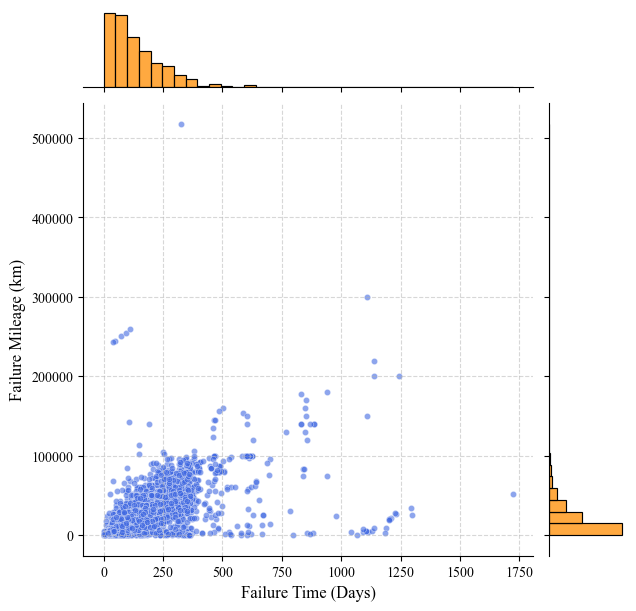

In [1]:
# CELL 9: 变量相关性初步探究 (Correlation & Joint Distribution)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['font.family'] = 'Times New Roman'
copula_dir = os.path.join("result", "copula_analysis")
os.makedirs(copula_dir, exist_ok=True)

# 1. 载入原始干净数据 (时间和里程天然绑定于同一个观察序列中)
try:
    df_final = pd.read_csv('cleaned_data.csv')
    t_data = df_final['fail_time'].dropna().values
    x_data = df_final['mileage_val'].dropna().values
except Exception as e:
    print("Error loading data:", e)

# 2. 定量计算三个核心相关性系数 (Pearson / Spearman / Kendall)
corr_pearson, p_p = stats.pearsonr(t_data, x_data)
corr_spearman, p_s = stats.spearmanr(t_data, x_data)
corr_kendall, p_k = stats.kendalltau(t_data, x_data)

print("=== Bivariate Correlation Analysis ===")
print(f"Pearson's r:   {corr_pearson:.4f} \t(p-value: {p_p:.2e})")
print(f"Spearman's ρ:  {corr_spearman:.4f} \t(p-value: {p_s:.2e})")
print(f"Kendall's τ:   {corr_kendall:.4f} \t(p-value: {p_k:.2e})")

# 3. 绘制带有边缘分布直方图的联合分布散点图
print("\nPlotting Joint Scatter with Marginal Histograms... (saved to result/copula_analysis/)")
g = sns.jointplot(x=t_data, y=x_data, kind="scatter", 
                  color="royalblue", alpha=0.6, s=20,
                  marginal_kws=dict(bins=35, fill=True, color="darkorange"))

g.ax_joint.set_xlabel('Failure Time (Days)', fontsize=12)
g.ax_joint.set_ylabel('Failure Mileage (km)', fontsize=12)
g.ax_joint.grid(True, linestyle='--', alpha=0.5)

# 纯粹图例，不加Title
plt.savefig(os.path.join(copula_dir, "Bivariate_Joint_Distribution.svg"), format='svg', bbox_inches='tight')
plt.show()


In [2]:
# CELL 10: 基于两类伪观测数据的 Copula 参数极大似然拟合
import warnings
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

# 1. 【核心路线 A】：构造全局经验伪观测点（Empirical Pseudo-Observations）
# 无视物理分布偏见，精准提取原始单调相关性
N = len(t_data)
u_emp = stats.rankdata(t_data) / (N + 1)
v_emp = stats.rankdata(x_data) / (N + 1)

# 2. 【核心路线 B】：构造标准参数伪观测点（Parametric Pseudo-Observations）
# 遵照指示，时间轴强制拟合2参数Gamma，里程轴强制拟合2参数Weibull
p_gamma = stats.gamma.fit(t_data, floc=0)
u_par = stats.gamma.cdf(t_data, p_gamma[0], scale=p_gamma[2])

p_weibull = stats.weibull_min.fit(x_data, floc=0)
v_par = stats.weibull_min.cdf(x_data, p_weibull[0], scale=p_weibull[2])

# 防止积分下溢导致浮点计算崩溃(极小的数在对数方程中引发除以0爆炸)，做截断保护
u_par = np.clip(u_par, 1e-4, 1.0 - 1e-4)
v_par = np.clip(v_par, 1e-4, 1.0 - 1e-4)

# ==================================
# 严密的手写级 Copula 偏导密度推演核心
# （避免第三方陈旧包兼容报错，原汁原味解析）
# ==================================
def c_clayton(theta, u, v):
    # 下尾高度相关 / 捕捉同期早期失效
    t1 = np.maximum(u**(-theta) + v**(-theta) - 1.0, 1e-10)
    pdf = (1.0 + theta) * (u*v)**(-theta - 1.0) * (t1)**(-2.0 - 1.0/theta)
    return np.clip(pdf, 1e-20, None)

def c_gumbel(theta, u, v):
    # 上尾高度相关 / 捕捉晚期磨损寿命末期联动
    lu, lv = -np.log(u), -np.log(v)
    t1 = np.maximum(lu**theta + lv**theta, 1e-10)
    C = np.exp(-t1**(1.0/theta))
    pdf = C * (u*v)**(-1.0) * (lu*lv)**(theta-1.0) * t1**(2.0/theta - 2.0) * (t1**(1.0/theta) + theta - 1.0)
    return np.clip(pdf, 1e-20, None)

def c_frank(theta, u, v):
    # 对等相关对称型 Copula
    num = -theta * (np.exp(-theta) - 1.0) * np.exp(-theta*(u+v))
    den = (np.exp(-theta*u) - 1.0) * (np.exp(-theta*v) - 1.0) + (np.exp(-theta) - 1.0)
    pdf = num / np.maximum(den**2, 1e-20)
    return np.clip(pdf, 1e-20, None)

def c_gaussian(rho, u, v):
    # 基础高斯底座 Copula
    x, y = stats.norm.ppf(u), stats.norm.ppf(v)
    rho = np.clip(rho, -0.99, 0.99)
    term = (x**2 + y**2 - 2*rho*x*y) / (2*(1.0 - rho**2))
    pdf = (1.0 / np.sqrt(1.0 - rho**2)) * np.exp(-term + (x**2 + y**2)/2.0)
    return np.clip(pdf, 1e-20, None)

def run_copula_fitting(u_seq, v_seq, track_label):
    print(f"\n--- Estimating 4 Copulas on [{track_label}] ---")
    results = []
    
    # 将寻找最优参数定义为寻找使得联合对数似然概率(NLL)为负极小值的最优化命题
    nll_c = lambda t: -np.sum(np.log(c_clayton(t[0], u_seq, v_seq)))
    nll_g = lambda t: -np.sum(np.log(c_gumbel(t[0], u_seq, v_seq)))
    nll_f = lambda t: -np.sum(np.log(c_frank(t[0], u_seq, v_seq)))
    nll_gauss = lambda r: -np.sum(np.log(c_gaussian(r[0], u_seq, v_seq)))
    
    # L-BFGS-B 带约束极值边界寻优法
    res_c = minimize(nll_c, [1.5], bounds=[(1e-2, 25)])
    aic_c = 2 * 1 + 2 * res_c.fun
    results.append({'Copula': 'Clayton', 'Margin System': track_label, 'Theta Parameter': res_c.x[0], 'NLL': res_c.fun, 'AIC': aic_c})
    
    res_g = minimize(nll_g, [1.5], bounds=[(1.001, 25)])
    aic_g = 2 * 1 + 2 * res_g.fun
    results.append({'Copula': 'Gumbel', 'Margin System': track_label, 'Theta Parameter': res_g.x[0], 'NLL': res_g.fun, 'AIC': aic_g})
    
    res_f = minimize(nll_f, [5.0], bounds=[(1e-2, 35)])
    aic_f = 2 * 1 + 2 * res_f.fun
    results.append({'Copula': 'Frank', 'Margin System': track_label, 'Theta Parameter': res_f.x[0], 'NLL': res_f.fun, 'AIC': aic_f})
    
    res_gauss = minimize(nll_gauss, [0.5], bounds=[(-0.99, 0.99)])
    aic_gauss = 2 * 1 + 2 * res_gauss.fun
    results.append({'Copula': 'Gaussian', 'Margin System': track_label, 'Theta (Rho)': res_gauss.x[0], 'NLL': res_gauss.fun, 'AIC': aic_gauss})
    
    df_res = pd.DataFrame(results).sort_values(by='AIC', ascending=True)
    display(df_res)
    return df_res

df_emp_copula = run_copula_fitting(u_emp, v_emp, "Empirical Baseline")
df_par_copula = run_copula_fitting(u_par, v_par, "Parametric Baseline (Time:Gamma-2 | Mileage:Weibull-2)")

df_emp_copula.to_csv(os.path.join(copula_dir, "copula_gof_empirical.csv"), index=False)
df_par_copula.to_csv(os.path.join(copula_dir, "copula_gof_parametric.csv"), index=False)



--- Estimating 4 Copulas on [Empirical Baseline] ---


,Copula,Margin System,Theta Parameter,NLL,AIC,Theta (Rho)
2,Frank,Empirical Baseline,7.849201,-2347.570426,-4693.140852,NaN
3,Gaussian,Empirical Baseline,NaN,-1834.003277,-3666.006554,0.713547
1,Gumbel,Empirical Baseline,1.707295,-1748.841095,-3495.682190,NaN
0,Clayton,Empirical Baseline,1.493650,-1488.572889,-2975.145778,NaN



--- Estimating 4 Copulas on [Parametric Baseline (Time:Gamma-2 | Mileage:Weibull-2)] ---


,Copula,Margin System,Theta Parameter,NLL,AIC,Theta (Rho)
2,Frank,Parametric Baseline (Time:Gamma-2 | Mileage:We...,7.905938,-2324.339577,-4646.679153,NaN
3,Gaussian,Parametric Baseline (Time:Gamma-2 | Mileage:We...,NaN,-1700.746865,-3399.493730,0.696385
1,Gumbel,Parametric Baseline (Time:Gamma-2 | Mileage:We...,1.632254,-1696.696270,-3391.392540,NaN
0,Clayton,Parametric Baseline (Time:Gamma-2 | Mileage:We...,1.492456,-1402.033008,-2802.066016,NaN


Plotting optimal structural dependency model: Frank Copula (Parameter θ = 7.8492)


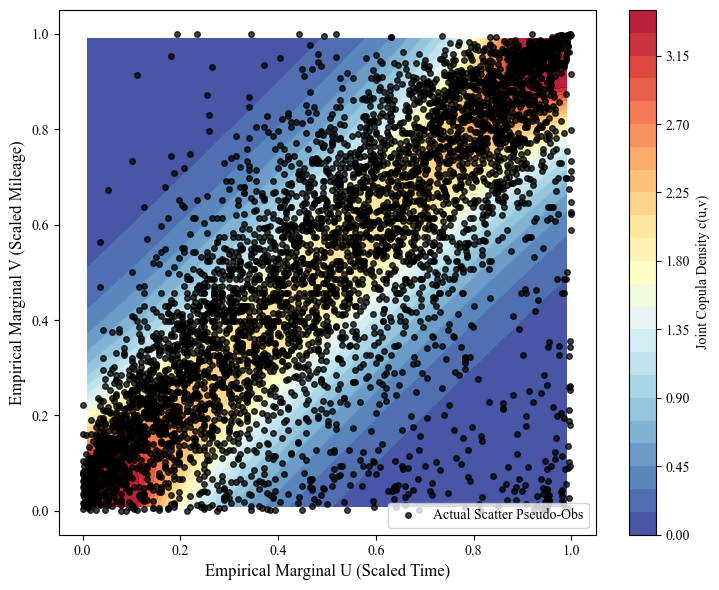

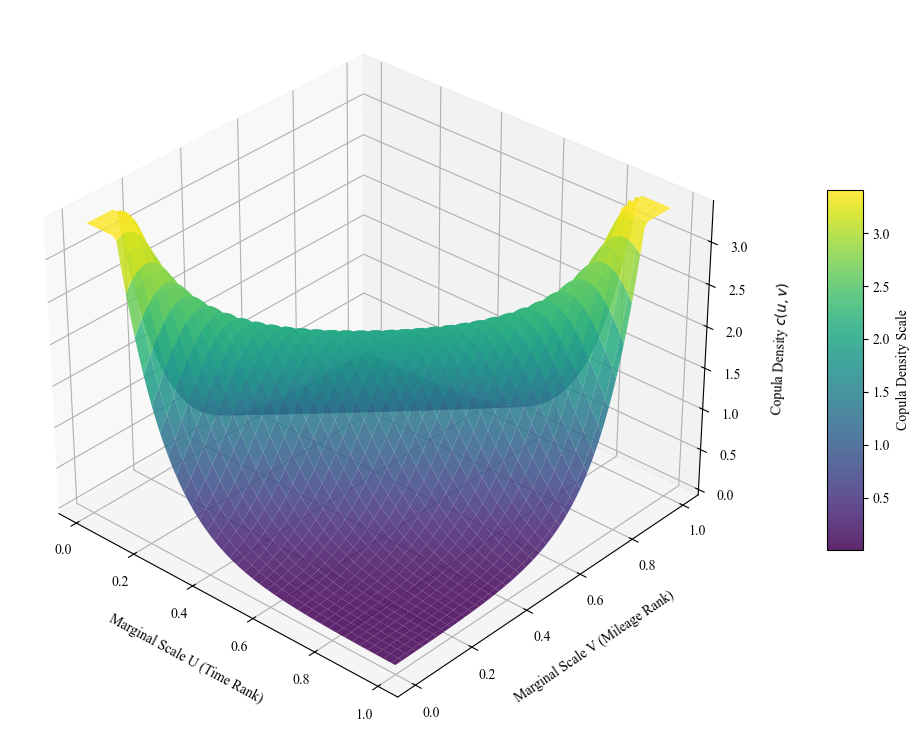

In [3]:
# CELL 11: 胜出者 Copula 的顶级 3D 密度解剖图与 2D Contours 等高散点映射
from mpl_toolkits.mplot3d import Axes3D

# 这里智能抽取了上一个代码块算出的最强拟合函数（AIC打分最低的即最优秀的，通常排在第一排iloc[0]）
# 使用非参 Empirical 作为画图表现底座最精确
best_model = df_emp_copula.iloc[0]
best_copula_name = best_model['Copula']
opt_theta = best_model.get('Theta Parameter', best_model.get('Theta (Rho)'))

print(f"Plotting optimal structural dependency model: {best_copula_name} Copula (Parameter θ = {opt_theta:.4f})")

# 1. 构建超高清单调密度绘图用 2D 点阵网络
grid_len = 80
u_grid = np.linspace(0.01, 0.99, grid_len)
v_grid = np.linspace(0.01, 0.99, grid_len)
U, V = np.meshgrid(u_grid, v_grid)

if best_copula_name == 'Clayton':
    Z = c_clayton(opt_theta, U, V)
elif best_copula_name == 'Gumbel':
    Z = c_gumbel(opt_theta, U, V)
elif best_copula_name == 'Frank':
    Z = c_frank(opt_theta, U, V)
else:
    Z = c_gaussian(opt_theta, U, V)
    
# 防止尾部相关性极高导致的坐标系Z轴炸裂，对其视觉高度进行P98柔和压顶处理
Z = np.clip(Z, 0, np.percentile(Z, 98))

# ================================
# Output Plot 1：等高线 Contour 混合散点碰撞对比 2D
# ================================
plt.figure(figsize=(7.5, 6))
contour = plt.contourf(U, V, Z, levels=25, cmap='RdYlBu_r', alpha=0.9)
plt.colorbar(contour, label='Joint Copula Density c(u,v)')

# 叠加真实世界的车辆失效观测点矩阵
plt.scatter(u_emp, v_emp, color='black', s=16, alpha=0.75, label='Actual Scatter Pseudo-Obs')

plt.xlabel('Empirical Marginal U (Scaled Time)', fontsize=12)
plt.ylabel('Empirical Marginal V (Scaled Mileage)', fontsize=12)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(copula_dir, f"Best_{best_copula_name}_Contour_2D.svg"), format='svg')
plt.show()


# ================================
# Output Plot 2：Copula 三维概率密度连贯立体曲面 (3D Surface Analysis)
# ================================
fig = plt.figure(figsize=(10, 7.5))
ax = fig.add_subplot(111, projection='3d')

# 抗锯齿着色投射渲染
surf = ax.plot_surface(U, V, Z, cmap='viridis', edgecolor='none', alpha=0.85)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1, label='Copula Density Scale')
ax.set_xlabel('Marginal Scale U (Time Rank)', labelpad=10)
ax.set_ylabel('Marginal Scale V (Mileage Rank)', labelpad=10)
ax.set_zlabel('Copula Density $c(u,v)$', labelpad=10)

# 设置完美的对角环绕斜视俯拍角度
ax.view_init(elev=32, azim=-48) 

plt.tight_layout()
plt.savefig(os.path.join(copula_dir, f"Best_{best_copula_name}_3DSurface.svg"), format='svg')
plt.show()
